# Comprehensive Exploratory Data Analysis on Smartphone Dataset

This notebook performs a detailed exploratory data analysis (EDA) on a smartphone dataset to uncover insights, patterns, and relationships within the data. The analysis will help us understand the smartphone market better and identify factors that influence pricing.

## EDA Structure:

1. **Data Loading & Initial Exploration**
   - Dataset overview and basic statistics
   - Checking data types and missing values
   - Summary statistics

2. **Univariate Analysis**
   - Distribution of numeric features
   - Distribution of categorical features
   - Price distribution analysis (our target variable)

3. **Bivariate Analysis**
   - Relationship between price and other features
   - Correlation analysis
   - Brand-specific insights

4. **Multivariate Analysis**
   - Feature interactions
   - Price category analysis across multiple features

5. **Feature Engineering Insights**
   - Important features for price prediction
   - Feature transformation recommendations
   
6. **Conclusions and Recommendations**
   - Key findings from the analysis
   - Next steps for modeling

In [4]:
# importing nessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# setting the style of seaborn
sns.set_style("whitegrid")

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# reading the dataset
df = pd.read_csv('smartphone_cleaned_v5.csv')

In [5]:
df.shape

(980, 25)

In [6]:
df.head()

,brand_name,model,price,rating,has_5g,has_nfc,has_ir_blaster,processor_brand,num_cores,processor_speed,battery_capacity,fast_charging_available,fast_charging,ram_capacity,internal_memory,screen_size,refresh_rate,resolution,num_rear_cameras,num_front_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto
0,oneplus,OnePlus 11 5G,54999,89.0,True,True,False,snapdragon,8.0,3.2,5000.0,1,100.0,12.0,256.0,6.70,120,1440 x 3216,3,1.0,android,50.0,16.0,0,NaN
1,oneplus,OnePlus Nord CE 2 Lite 5G,19989,81.0,True,False,False,snapdragon,8.0,2.2,5000.0,1,33.0,6.0,128.0,6.59,120,1080 x 2412,3,1.0,android,64.0,16.0,1,1024.0
2,samsung,Samsung Galaxy A14 5G,16499,75.0,True,False,False,exynos,8.0,2.4,5000.0,1,15.0,4.0,64.0,6.60,90,1080 x 2408,3,1.0,android,50.0,13.0,1,1024.0
3,motorola,Motorola Moto G62 5G,14999,81.0,True,False,False,snapdragon,8.0,2.2,5000.0,1,NaN,6.0,128.0,6.55,120,1080 x 2400,3,1.0,android,50.0,16.0,1,1024.0
4,realme,Realme 10 Pro Plus,24999,82.0,True,False,False,dimensity,8.0,2.6,5000.0,1,67.0,6.0,128.0,6.70,120,1080 x 2412,3,1.0,android,108.0,16.0,0,NaN


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 980 entries, 0 to 979
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   brand_name                 980 non-null    object 
 1   model                      980 non-null    object 
 2   price                      980 non-null    int64  
 3   rating                     879 non-null    float64
 4   has_5g                     980 non-null    bool   
 5   has_nfc                    980 non-null    bool   
 6   has_ir_blaster             980 non-null    bool   
 7   processor_brand            960 non-null    object 
 8   num_cores                  974 non-null    float64
 9   processor_speed            938 non-null    float64
 10  battery_capacity           969 non-null    float64
 11  fast_charging_available    980 non-null    int64  
 12  fast_charging              769 non-null    float64
 13  ram_capacity               980 non-null    float64

In [8]:
df.isnull().sum()

brand_name                     0
model                          0
price                          0
rating                       101
has_5g                         0
has_nfc                        0
has_ir_blaster                 0
processor_brand               20
num_cores                      6
processor_speed               42
battery_capacity              11
fast_charging_available        0
fast_charging                211
ram_capacity                   0
internal_memory                0
screen_size                    0
refresh_rate                   0
resolution                     0
num_rear_cameras               0
num_front_cameras              4
os                            14
primary_camera_rear            0
primary_camera_front           5
extended_memory_available      0
extended_upto                480
dtype: int64

## 1. Data Overview and Initial Exploration

Let's start by understanding the basic structure of our dataset, including data types, missing values, and summary statistics.

In [9]:
# Comprehensive data overview
print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns")

# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Data types summary
print("\nData Types:")
data_types = df.dtypes.value_counts()
print(data_types)

# Missing values summary
print("\nMissing Values Summary:")
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing_values, 'Percent': missing_percent})
missing_df = missing_df[missing_df['Count'] > 0].sort_values('Percent', ascending=False)
print(missing_df)

# Summary statistics for numeric columns
print("\nNumeric Columns Summary Statistics:")
print(df.describe().T.round(2))

# Categorical columns overview
print("\nCategorical Columns Overview:")
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts().head(5))

# Boolean columns overview
bool_cols = df.select_dtypes(include=['bool']).columns.tolist()
if bool_cols:
    print("\nBoolean Columns Overview:")
    for col in bool_cols:
        print(f"\n{col}:")
        print(df[col].value_counts())

# Identifying potential outliers in numeric columns
print("\nPotential Outliers in Numeric Columns (using IQR method):")
num_cols = df.select_dtypes(include=[np.number]).columns
outliers_summary = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    if len(outliers) > 0:
        outliers_summary[col] = (len(outliers), round(len(outliers)/len(df)*100, 2))

for col, (count, percent) in outliers_summary.items():
    print(f"{col}: {count} outliers ({percent}%)")

Dataset Shape: 980 rows and 25 columns
Number of duplicate rows: 0

Data Types:
float64    12
object      5
int64       5
bool        3
Name: count, dtype: int64

Missing Values Summary:
                      Count  Percent
extended_upto           480    48.98
fast_charging           211    21.53
rating                  101    10.31
processor_speed          42     4.29
processor_brand          20     2.04
os                       14     1.43
battery_capacity         11     1.12
num_cores                 6     0.61
primary_camera_front      5     0.51
num_front_cameras         4     0.41

Numeric Columns Summary Statistics:
                           count      mean       std      min       25%  \
price                      980.0  32520.50  39531.81  3499.00  12999.00   
rating                     879.0     78.26      7.40    60.00     74.00   
num_cores                  974.0      7.77      0.84     4.00      8.00   
processor_speed            938.0      2.43      0.46     1.20      2.

<Axes: xlabel='brand_name'>

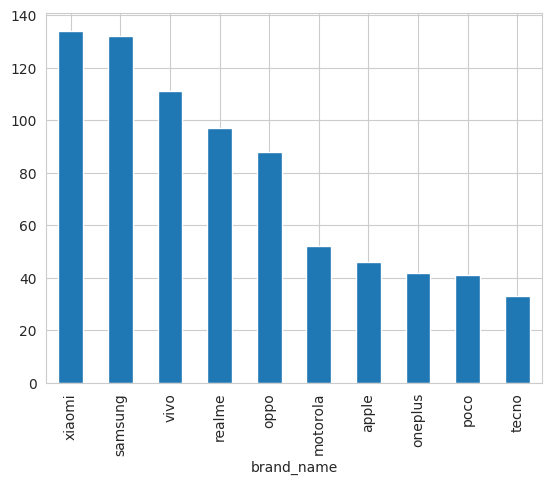

In [10]:
# plot a graph of top 10 brands
df['brand_name'].value_counts().head(10).plot(kind = 'bar')

## 2. Univariate Analysis

In this section, we'll explore the distribution of individual features to understand their characteristics.

<Axes: ylabel='count'>

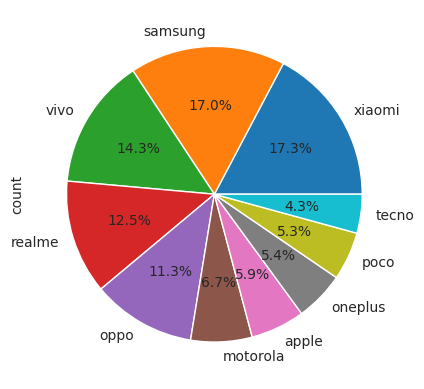

In [11]:
df['brand_name'].value_counts().head(10).plot(kind = 'pie', autopct='%1.1f%%')

### 2.1 Categorical Features Analysis

Let's analyze the distribution of key categorical features such as brand names, processor brands, and operating systems.

Brand Analysis:
Total brands: 46

Top 10 brands by market share:
brand_name
xiaomi      134
samsung     132
vivo        111
realme       97
oppo         88
motorola     52
apple        46
oneplus      42
poco         41
tecno        33
Name: count, dtype: int64

Percentage of market covered by top 10 brands: 79.18%


/tmp/ipykernel_120050/2865708263.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['brand_name'], order=df['brand_name'].value_counts().index[:10], palette='viridis')
/tmp/ipykernel_120050/2865708263.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['processor_brand'], order=df['processor_brand'].value_counts().index[:8], palette='magma')
/tmp/ipykernel_120050/2865708263.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['os'], order=df['os'].value_counts().index, palette='plasma')
/tmp/ipykernel_120050/286570826

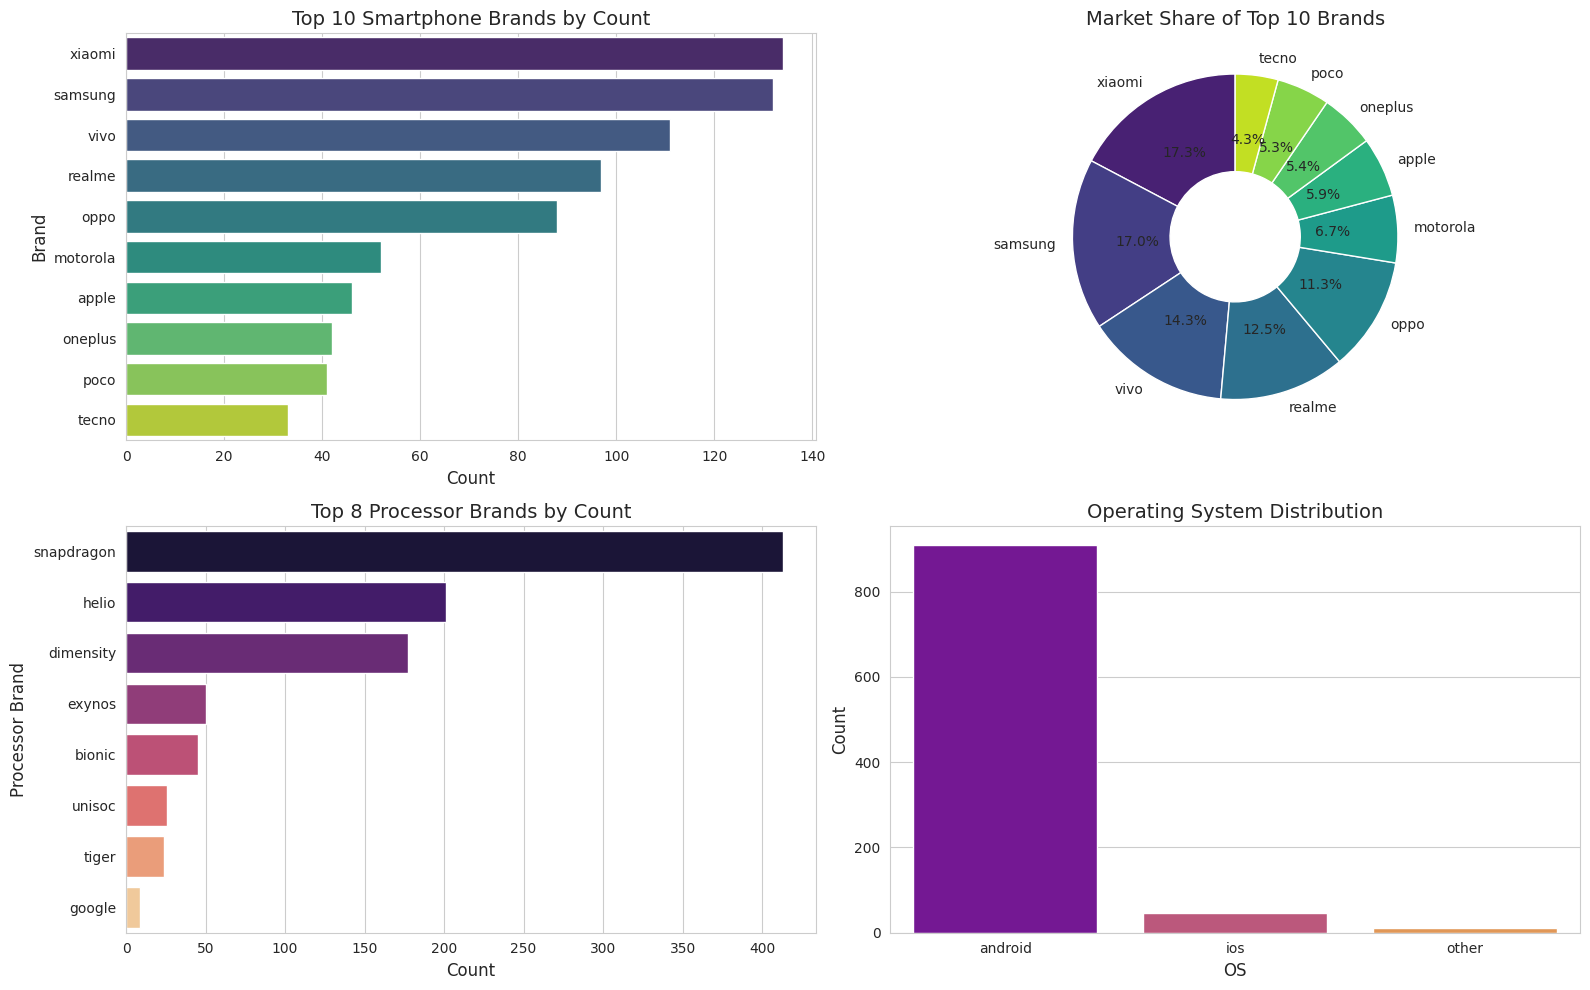

/tmp/ipykernel_120050/2865708263.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['has_5g'], palette=['lightcoral', 'lightgreen'])
/tmp/ipykernel_120050/2865708263.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['has_nfc'], palette=['lightcoral', 'lightgreen'])
/tmp/ipykernel_120050/2865708263.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['has_ir_blaster'], palette=['lightcoral', 'lightgreen'])
/tmp/ipykernel_120050/2865708263.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated

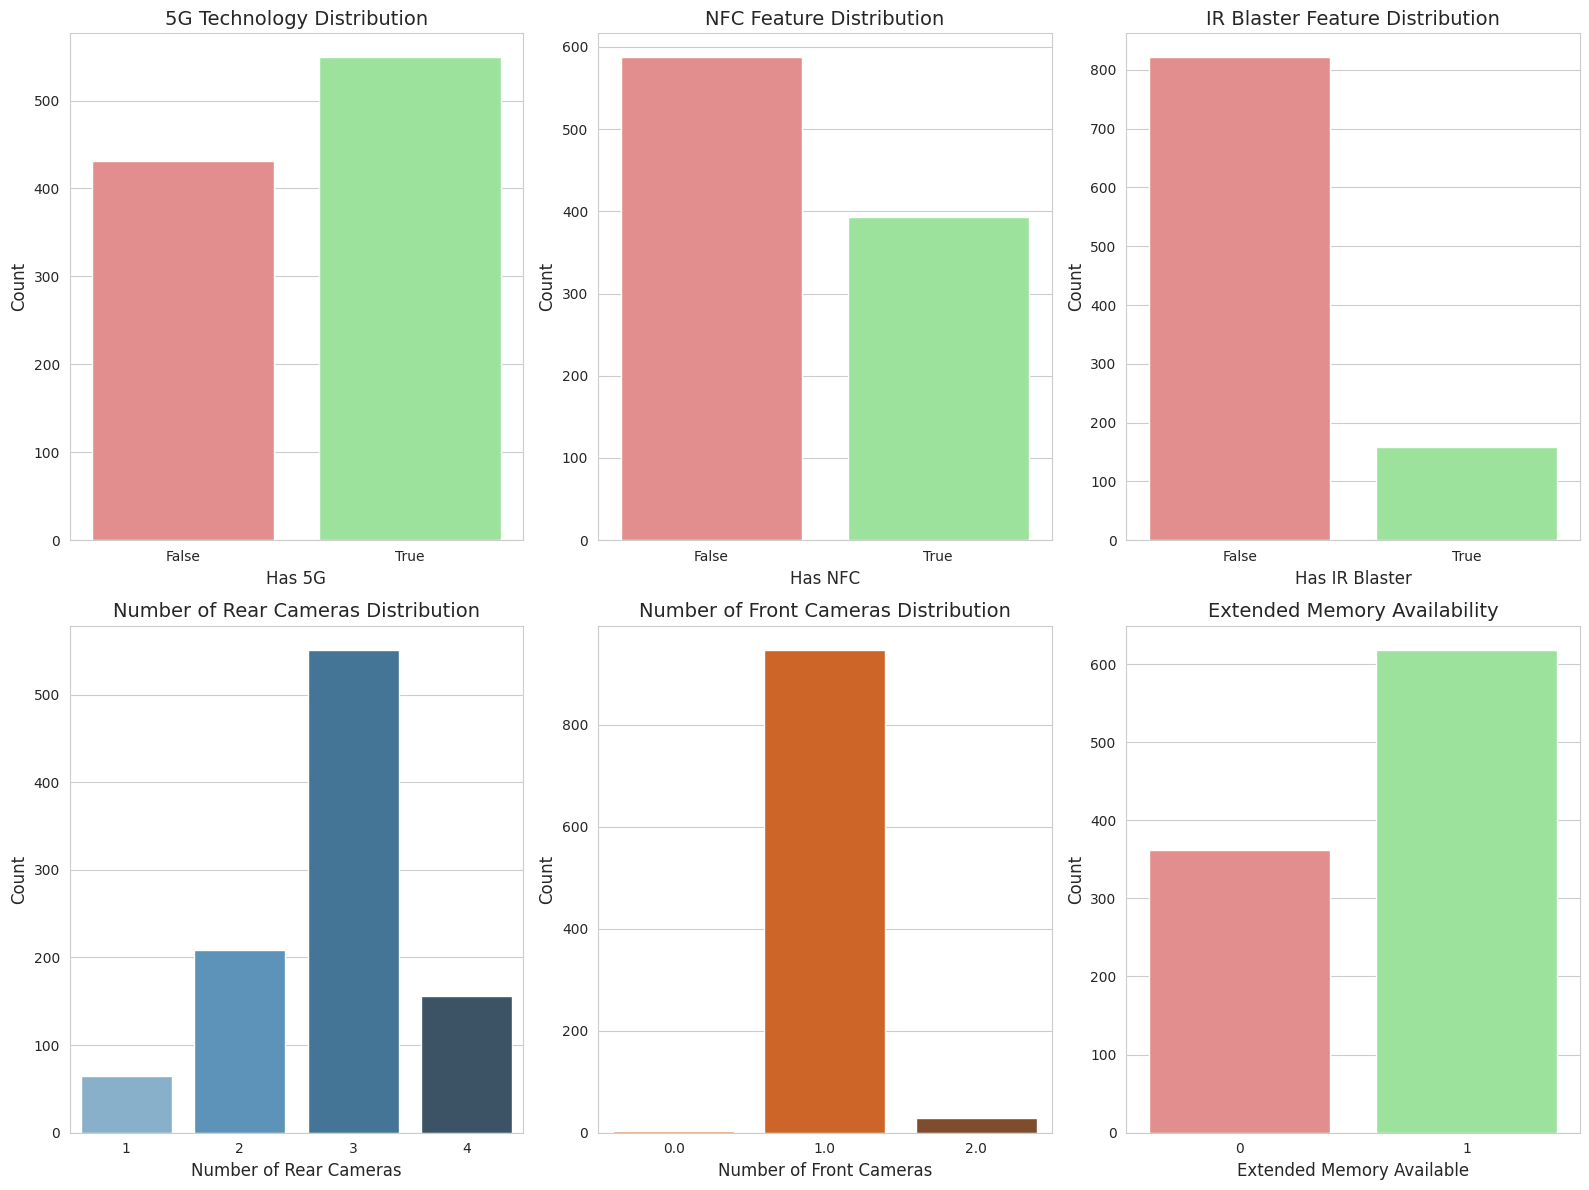


Feature Presence Statistics:
------------------------------
5G: 549 devices (56.0%)
Nfc: 393 devices (40.1%)
Ir Blaster: 159 devices (16.2%)
Extended Memory Available: 618 devices (63.1%)

Processor Brand Distribution:
snapdragon: 413 devices (42.1%)
helio: 201 devices (20.5%)
dimensity: 177 devices (18.1%)
exynos: 50 devices (5.1%)
bionic: 45 devices (4.6%)

Operating System Distribution:
android: 909 devices (94.1%)
ios: 46 devices (4.8%)
other: 11 devices (1.1%)


In [12]:
# Comprehensive analysis of categorical features

# 1. Brand Analysis
print("Brand Analysis:")
print(f"Total brands: {df['brand_name'].nunique()}")
top_brands = df['brand_name'].value_counts().head(10)
print("\nTop 10 brands by market share:")
print(top_brands)
print(f"\nPercentage of market covered by top 10 brands: {top_brands.sum() / len(df) * 100:.2f}%")

# Create a figure for brand analysis
plt.figure(figsize=(16, 10))

# Brand distribution bar chart
plt.subplot(2, 2, 1)
sns.countplot(y=df['brand_name'], order=df['brand_name'].value_counts().index[:10], palette='viridis')
plt.title('Top 10 Smartphone Brands by Count', fontsize=14)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Brand', fontsize=12)

# Brand distribution pie chart
plt.subplot(2, 2, 2)
top_brands.plot(kind='pie', autopct='%1.1f%%', startangle=90, 
               colors=sns.color_palette('viridis', 10), 
               wedgeprops=dict(width=0.6, edgecolor='white'))
plt.title('Market Share of Top 10 Brands', fontsize=14)
plt.ylabel('')

# 2. Processor Brand Analysis
plt.subplot(2, 2, 3)
sns.countplot(y=df['processor_brand'], order=df['processor_brand'].value_counts().index[:8], palette='magma')
plt.title('Top 8 Processor Brands by Count', fontsize=14)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Processor Brand', fontsize=12)

# 3. Operating System Analysis
plt.subplot(2, 2, 4)
sns.countplot(x=df['os'], order=df['os'].value_counts().index, palette='plasma')
plt.title('Operating System Distribution', fontsize=14)
plt.xlabel('OS', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show()

# 4. Additional Categorical Features Analysis
plt.figure(figsize=(16, 12))

# Feature presence analysis (5G, NFC, IR Blaster)
plt.subplot(2, 3, 1)
sns.countplot(x=df['has_5g'], palette=['lightcoral', 'lightgreen'])
plt.title('5G Technology Distribution', fontsize=14)
plt.xlabel('Has 5G', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.subplot(2, 3, 2)
sns.countplot(x=df['has_nfc'], palette=['lightcoral', 'lightgreen'])
plt.title('NFC Feature Distribution', fontsize=14)
plt.xlabel('Has NFC', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.subplot(2, 3, 3)
sns.countplot(x=df['has_ir_blaster'], palette=['lightcoral', 'lightgreen'])
plt.title('IR Blaster Feature Distribution', fontsize=14)
plt.xlabel('Has IR Blaster', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Number of rear cameras distribution
plt.subplot(2, 3, 4)
sns.countplot(x=df['num_rear_cameras'], palette='Blues_d')
plt.title('Number of Rear Cameras Distribution', fontsize=14)
plt.xlabel('Number of Rear Cameras', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Number of front cameras distribution
plt.subplot(2, 3, 5)
sns.countplot(x=df['num_front_cameras'].fillna(0), palette='Oranges_d')
plt.title('Number of Front Cameras Distribution', fontsize=14)
plt.xlabel('Number of Front Cameras', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Extended memory availability
plt.subplot(2, 3, 6)
sns.countplot(x=df['extended_memory_available'], palette=['lightcoral', 'lightgreen'])
plt.title('Extended Memory Availability', fontsize=14)
plt.xlabel('Extended Memory Available', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show()

# 5. Numerical representation of categorical data
print("\nFeature Presence Statistics:")
print("-" * 30)

# Calculate percentage presence of features
feature_cols = ['has_5g', 'has_nfc', 'has_ir_blaster', 'extended_memory_available']
for col in feature_cols:
    present = df[col].sum()
    percent = (present / len(df)) * 100
    print(f"{col.replace('has_', '').replace('_', ' ').title()}: {present} devices ({percent:.1f}%)")

# Processor brand distribution
print("\nProcessor Brand Distribution:")
proc_distribution = df['processor_brand'].value_counts().head(5)
for brand, count in proc_distribution.items():
    print(f"{brand}: {count} devices ({count/len(df)*100:.1f}%)")

# OS distribution
print("\nOperating System Distribution:")
os_distribution = df['os'].value_counts()
for os, count in os_distribution.items():
    print(f"{os}: {count} devices ({count/df['os'].count()*100:.1f}%)")

In [13]:
# Price
df['price'].describe()

count       980.000000
mean      32520.504082
std       39531.812669
min        3499.000000
25%       12999.000000
50%       19994.500000
75%       35491.500000
max      650000.000000
Name: price, dtype: float64

### 2.2 Numeric Features Analysis

Let's analyze the distribution and characteristics of key numeric features in the dataset.

PRICE ANALYSIS (Target Variable)
----------------------------------------
count       980.00
mean      32520.50
std       39531.81
min        3499.00
25%       12999.00
50%       19994.50
75%       35491.50
max      650000.00
Name: price, dtype: float64

Price range: ₹3,499 to ₹650,000
Skewness: 6.59


/tmp/ipykernel_120050/3513453936.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['ram_capacity'], palette='Blues_d')
/tmp/ipykernel_120050/3513453936.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['internal_memory'], order=df['internal_memory'].value_counts().index[:8],


/tmp/ipykernel_120050/3513453936.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['refresh_rate'], order=[60, 90, 120, 144, 165, 240], palette='Purples_d')


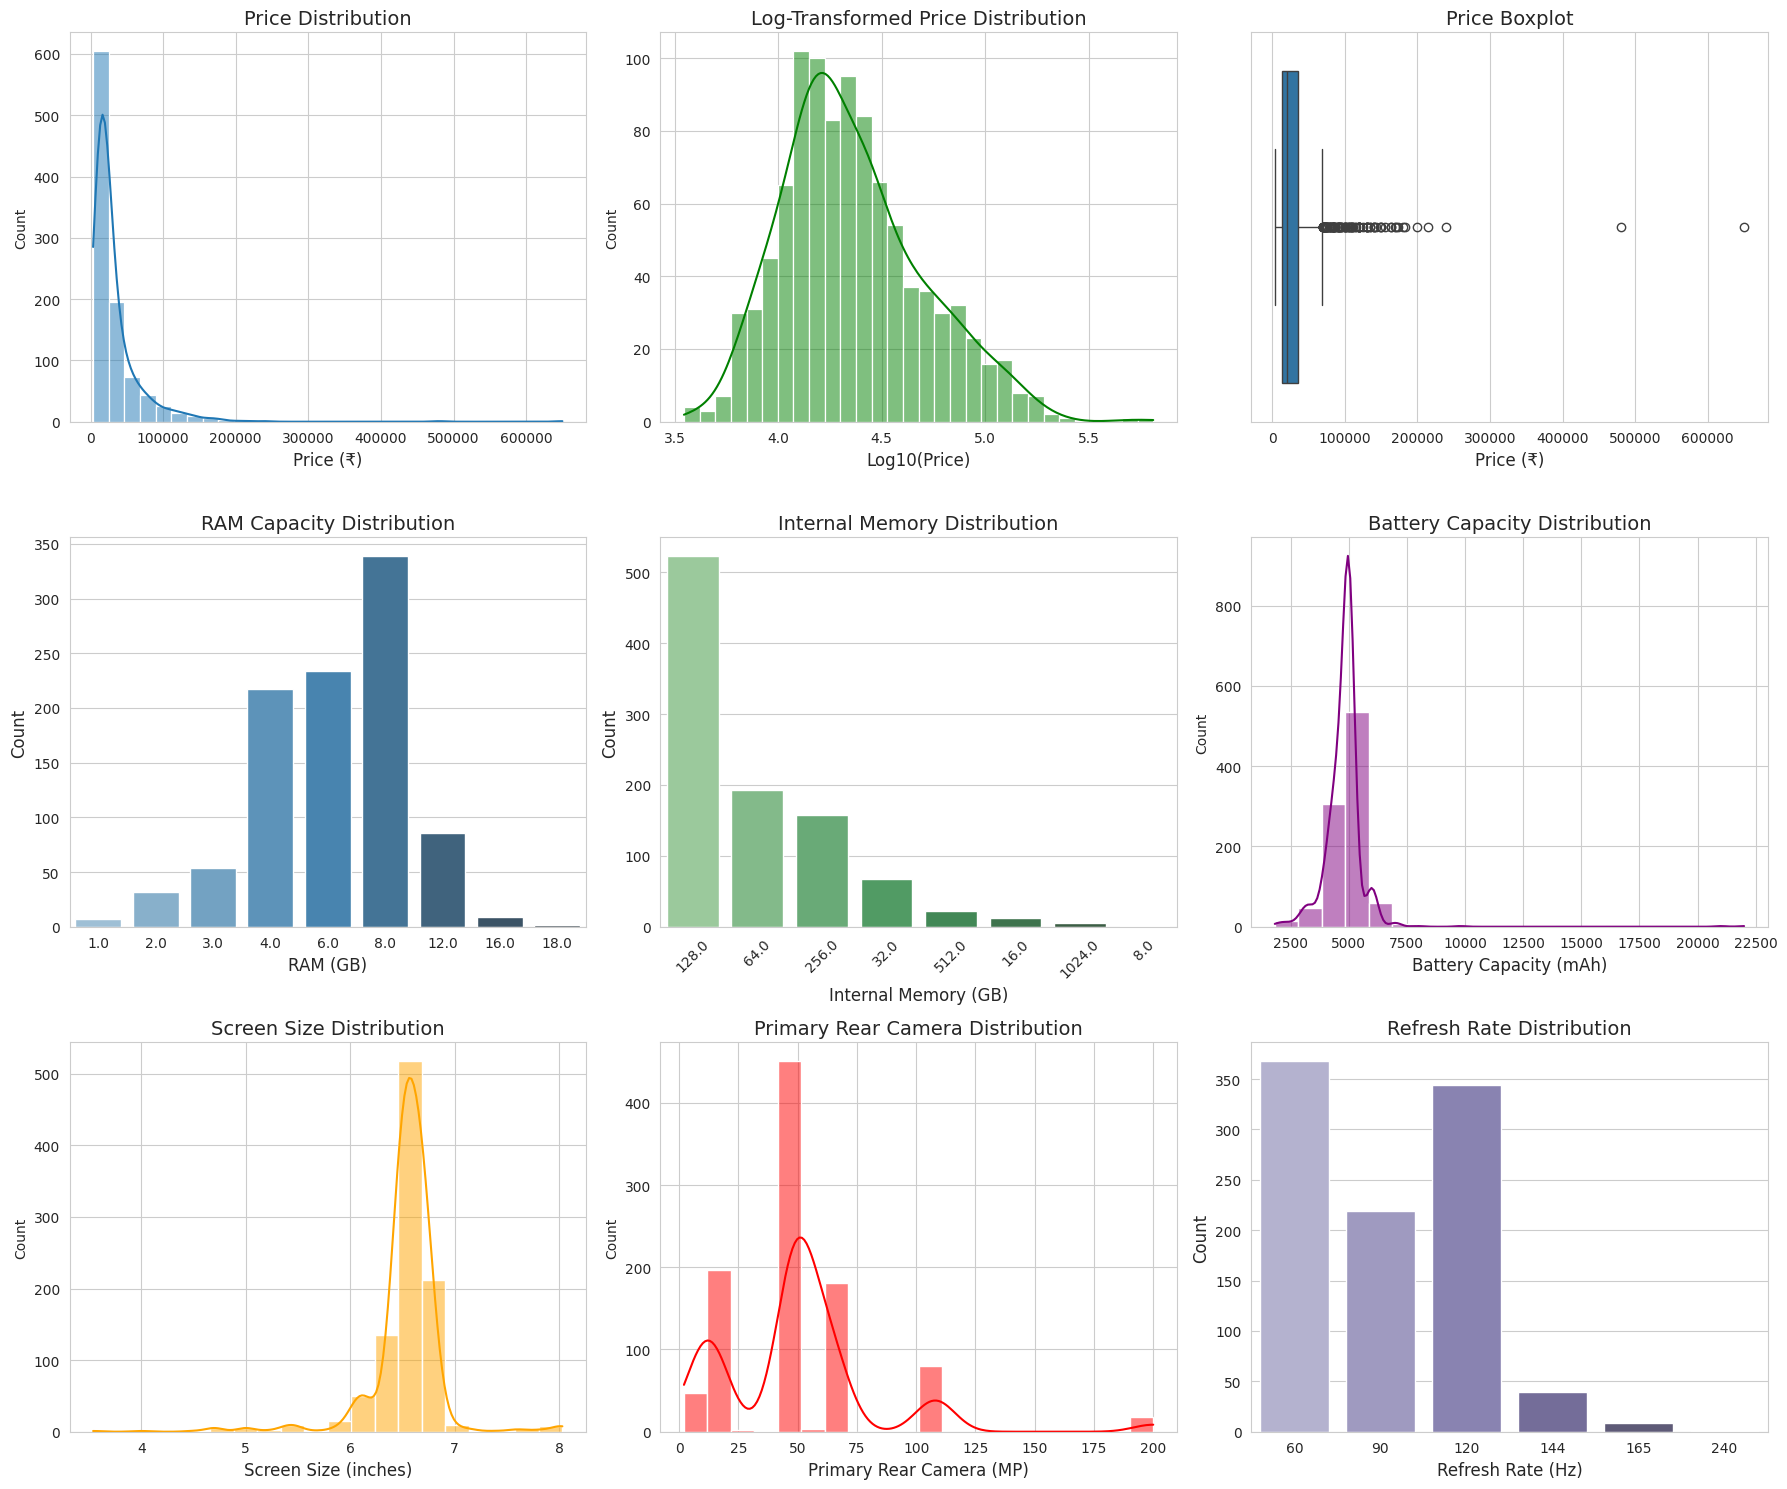


STATISTICAL SUMMARY OF KEY FEATURES:
----------------------------------------
                     count     mean      std      min     25%      50%  \
ram_capacity         980.0     6.56     2.74     1.00     4.0     6.00   
internal_memory      980.0   141.04   107.13     8.00    64.0   128.00   
battery_capacity     969.0  4817.75  1009.54  1821.00  4500.0  5000.00   
screen_size          980.0     6.54     0.35     3.54     6.5     6.58   
primary_camera_rear  980.0    50.32    33.00     2.00    24.0    50.00   
refresh_rate         980.0    92.26    28.99    60.00    60.0    90.00   

                         75%       max  skew  
ram_capacity            8.00     18.00  0.75  
internal_memory       128.00   1024.00  3.83  
battery_capacity     5000.00  22000.00  9.26  
screen_size             6.67      8.03 -2.12  
primary_camera_rear    64.00    200.00  1.77  
refresh_rate          120.00    240.00  0.30  

FEATURE PERCENTILES:
----------------------------------------

ram_capac

In [14]:
# Comprehensive analysis of key numeric features

# 1. Price Analysis (Target Variable)
print("PRICE ANALYSIS (Target Variable)")
print("-" * 40)
print(df['price'].describe().round(2))
print(f"\nPrice range: ₹{df['price'].min():,} to ₹{df['price'].max():,}")
print(f"Skewness: {df['price'].skew():.2f}")

# 2. Key Numeric Features
key_features = ['ram_capacity', 'internal_memory', 'battery_capacity', 
              'screen_size', 'primary_camera_rear', 'refresh_rate']

# Create a figure for numeric feature distributions
plt.figure(figsize=(18, 15))

# Price distribution with log transformation
plt.subplot(3, 3, 1)
sns.histplot(df['price'], kde=True, bins=30)
plt.title('Price Distribution', fontsize=14)
plt.xlabel('Price (₹)', fontsize=12)

plt.subplot(3, 3, 2)
sns.histplot(np.log10(df['price']), kde=True, bins=30, color='green')
plt.title('Log-Transformed Price Distribution', fontsize=14)
plt.xlabel('Log10(Price)', fontsize=12)

plt.subplot(3, 3, 3)
sns.boxplot(x=df['price'])
plt.title('Price Boxplot', fontsize=14)
plt.xlabel('Price (₹)', fontsize=12)

# RAM Distribution
plt.subplot(3, 3, 4)
sns.countplot(x=df['ram_capacity'], palette='Blues_d')
plt.title('RAM Capacity Distribution', fontsize=14)
plt.xlabel('RAM (GB)', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Internal Memory Distribution
plt.subplot(3, 3, 5)
sns.countplot(x=df['internal_memory'], order=df['internal_memory'].value_counts().index[:8], 
             palette='Greens_d')
plt.title('Internal Memory Distribution', fontsize=14)
plt.xlabel('Internal Memory (GB)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)

# Battery Capacity Distribution
plt.subplot(3, 3, 6)
sns.histplot(df['battery_capacity'], kde=True, bins=20, color='purple')
plt.title('Battery Capacity Distribution', fontsize=14)
plt.xlabel('Battery Capacity (mAh)', fontsize=12)

# Screen Size Distribution
plt.subplot(3, 3, 7)
sns.histplot(df['screen_size'], kde=True, bins=20, color='orange')
plt.title('Screen Size Distribution', fontsize=14)
plt.xlabel('Screen Size (inches)', fontsize=12)

# Primary Rear Camera Distribution
plt.subplot(3, 3, 8)
sns.histplot(df['primary_camera_rear'], kde=True, bins=20, color='red')
plt.title('Primary Rear Camera Distribution', fontsize=14)
plt.xlabel('Primary Rear Camera (MP)', fontsize=12)

# Refresh Rate Distribution
plt.subplot(3, 3, 9)
sns.countplot(x=df['refresh_rate'], order=[60, 90, 120, 144, 165, 240], palette='Purples_d')
plt.title('Refresh Rate Distribution', fontsize=14)
plt.xlabel('Refresh Rate (Hz)', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show()

# Statistical summary of key numeric features
print("\nSTATISTICAL SUMMARY OF KEY FEATURES:")
print("-" * 40)
features_stats = df[key_features].describe().T.round(2)
features_stats['skew'] = df[key_features].skew().round(2)  # Add skewness
print(features_stats)

# Distribution of features by percentiles
print("\nFEATURE PERCENTILES:")
print("-" * 40)
percentiles = [0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
for feature in key_features:
    print(f"\n{feature}:")
    for p in percentiles:
        value = df[feature].quantile(p)
        print(f"{p*100}th percentile: {value:.1f}")

# Top devices by price
print("\nTOP 10 MOST EXPENSIVE PHONES:")
print("-" * 40)
top10 = df.nlargest(10, 'price')[['brand_name', 'model', 'price', 'ram_capacity', 'internal_memory']]
print(top10)

print("\nTOP 10 LEAST EXPENSIVE PHONES:")
print("-" * 40)
bottom10 = df.nsmallest(10, 'price')[['brand_name', 'model', 'price', 'ram_capacity', 'internal_memory']]
print(bottom10)

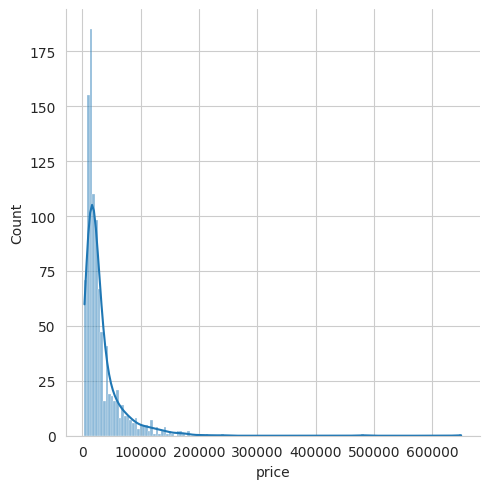

In [15]:
sns.displot(kind = 'hist', x='price', data=df, kde = True)

<Axes: xlabel='price'>

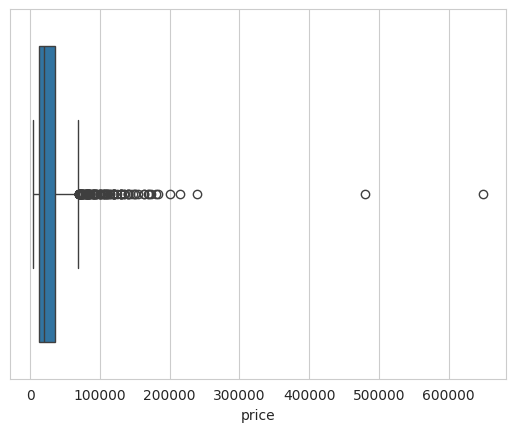

In [16]:
sns.boxplot(x=df['price'])

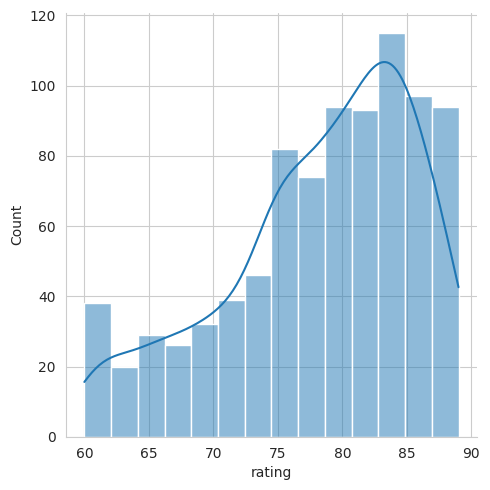

In [17]:
# Rating
df['rating'].describe()
sns.displot(kind = 'hist', x='rating', data=df, kde = True)

<Axes: xlabel='rating'>

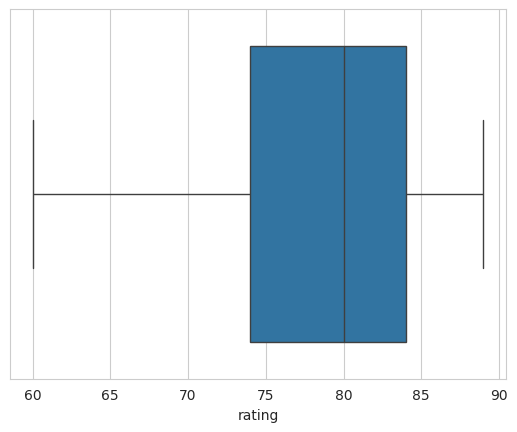

In [18]:
df['rating'].skew()
sns.boxplot(x=df['rating'])

In [19]:
# missing values
df['rating'].isnull().sum()/980

0.10306122448979592

<Axes: xlabel='has_5g', ylabel='count'>

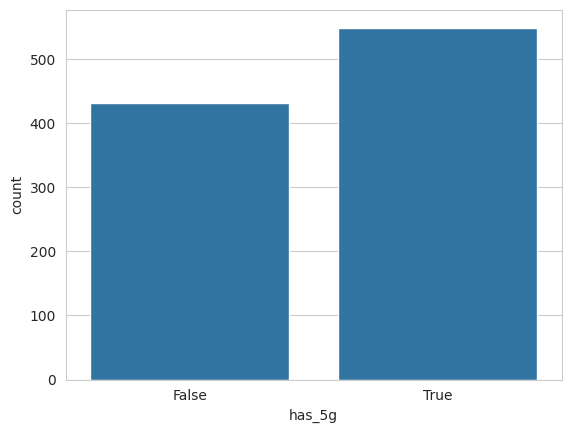

In [20]:
# has 5G
df['has_5g'].value_counts()
sns.countplot(x='has_5g', data=df)

<Axes: xlabel='has_nfc', ylabel='count'>

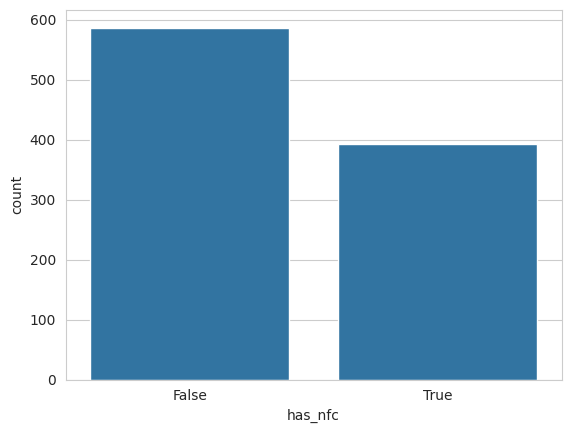

In [21]:
# NFC 
df['has_nfc'].value_counts()
sns.countplot(x='has_nfc', data=df)

<Axes: xlabel='has_ir_blaster', ylabel='count'>

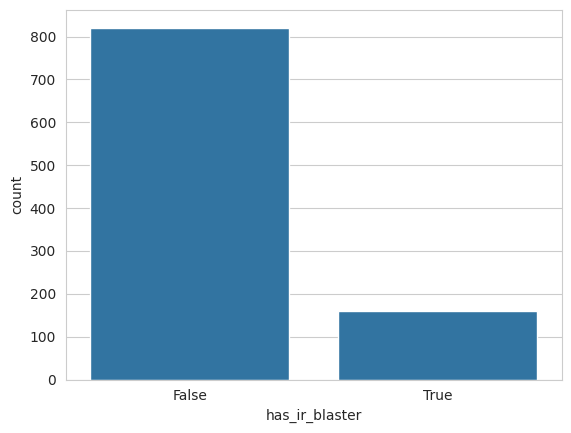

In [22]:
# IR Blaster
df['has_ir_blaster'].value_counts()
sns.countplot(x='has_ir_blaster', data=df)

<Axes: xlabel='processor_brand', ylabel='processor_brand'>

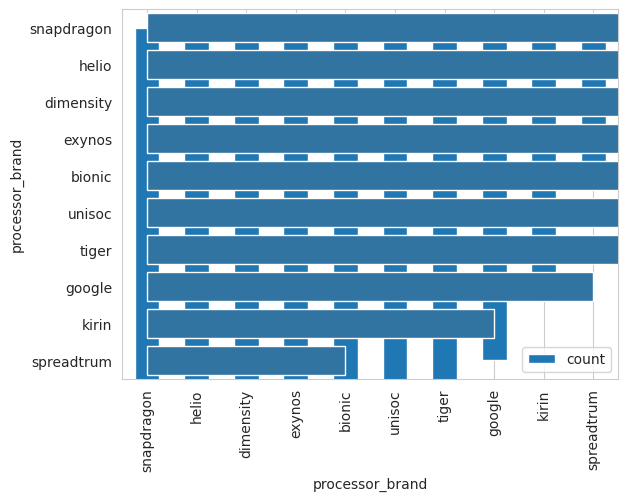

In [23]:
# processor_brand
df['processor_brand'].value_counts().head(10).plot(kind='bar')
sns.countplot(y='processor_brand', data=df, order=df['processor_brand'].value_counts().index[:10])

<Axes: xlabel='num_cores', ylabel='count'>

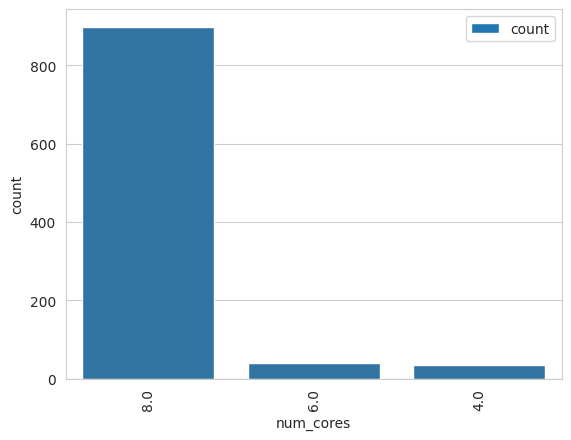

In [24]:
# num of cores
df['num_cores'].value_counts().head(10).plot(kind = 'bar')
sns.countplot(x = 'num_cores', data = df, order = df['num_cores'].value_counts().index[:10])

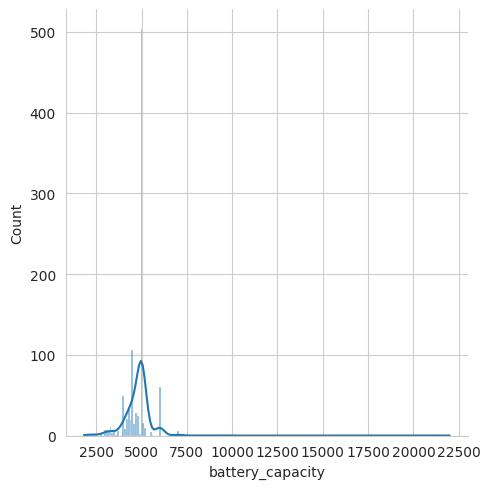

In [25]:
# battery capacity
df['battery_capacity'].describe()
sns.displot(kind = 'hist', x = 'battery_capacity', data = df, kde = True)

Fast charging distribution:
fast_charging
33.0     152
18.0     128
67.0      65
25.0      53
120.0     46
15.0      43
80.0      42
66.0      37
10.0      33
30.0      32
65.0      30
44.0      23
45.0      17
20.0      10
68.0       8
100.0      7
150.0      7
125.0      6
22.0       5
40.0       5
60.0       4
55.0       3
21.0       2
210.0      2
50.0       2
180.0      1
200.0      1
240.0      1
19.0       1
135.0      1
165.0      1
27.0       1
Name: count, dtype: int64

Missing values: 211


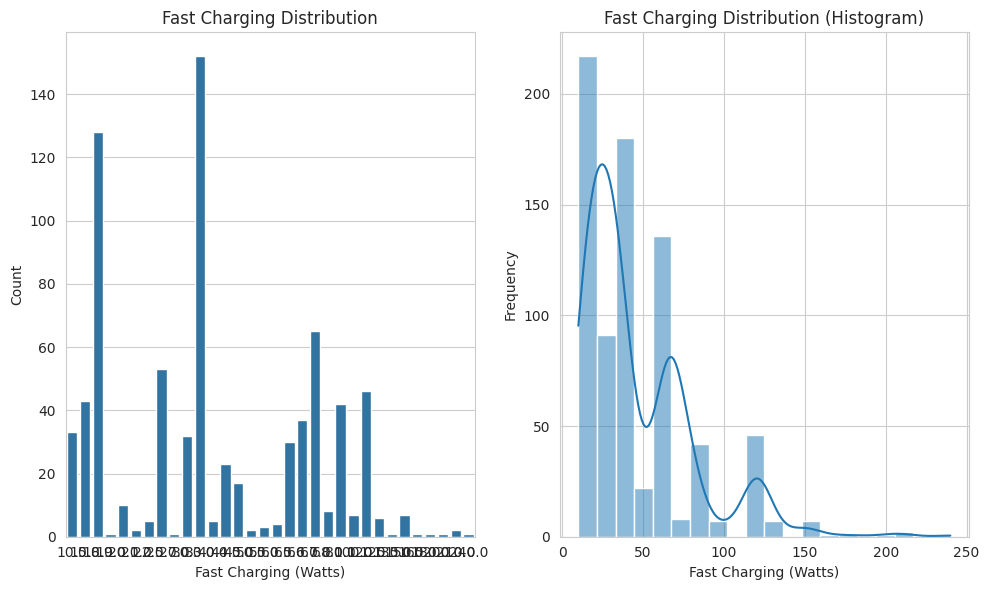


Fast charging summary statistics:
count    769.000000
mean      46.126138
std       34.277870
min       10.000000
25%       18.000000
50%       33.000000
75%       66.000000
max      240.000000
Name: fast_charging, dtype: float64


In [26]:
# Fast charging analysis
print("Fast charging distribution:")
print(df['fast_charging'].value_counts())
print(f"\nMissing values: {df['fast_charging'].isnull().sum()}")

# Visualize fast charging distribution
plt.figure(figsize=(10, 6))

# Count plot for fast charging values
plt.subplot(1, 2, 1)
sns.countplot(x='fast_charging', data=df)
plt.title('Fast Charging Distribution')
plt.xlabel('Fast Charging (Watts)')
plt.ylabel('Count')

# Histogram for fast charging values
plt.subplot(1, 2, 2)
sns.histplot(data=df, x='fast_charging', kde=True, bins=20)
plt.title('Fast Charging Distribution (Histogram)')
plt.xlabel('Fast Charging (Watts)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Summary statistics
print("\nFast charging summary statistics:")
print(df['fast_charging'].describe())

<Axes: xlabel='num_rear_cameras', ylabel='count'>

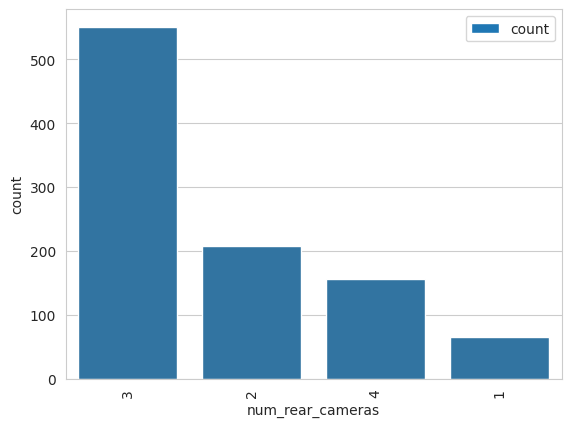

In [27]:
# No of rear cameras
df['num_rear_cameras'].value_counts().head(10).plot(kind='bar')
sns.countplot(x = 'num_rear_cameras', data = df, order = df['num_rear_cameras'].value_counts().index)

<Axes: xlabel='os', ylabel='os'>

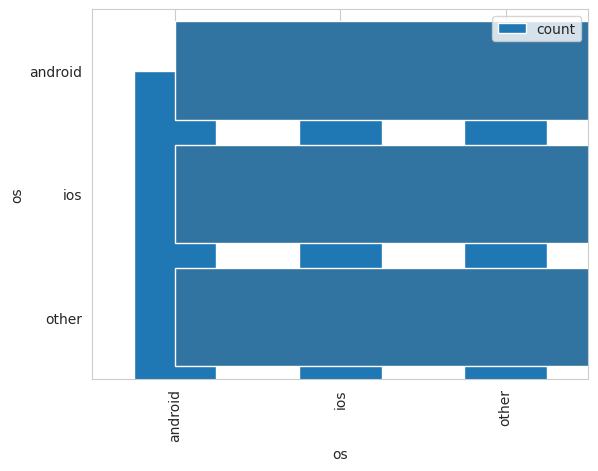

In [28]:
# OS
df['os'].value_counts().head(10).plot(kind='bar')
sns.countplot(y='os', data=df, order=df['os'].value_counts().index[:10])

BRAND NAME ANALYSIS
Total unique brands: 46
Total records: 980
Missing values: 0

Top 15 brands by count:
brand_name
xiaomi      134
samsung     132
vivo        111
realme       97
oppo         88
motorola     52
apple        46
oneplus      42
poco         41
tecno        33
iqoo         32
infinix      29
huawei       16
google       14
nokia        13
Name: count, dtype: int64


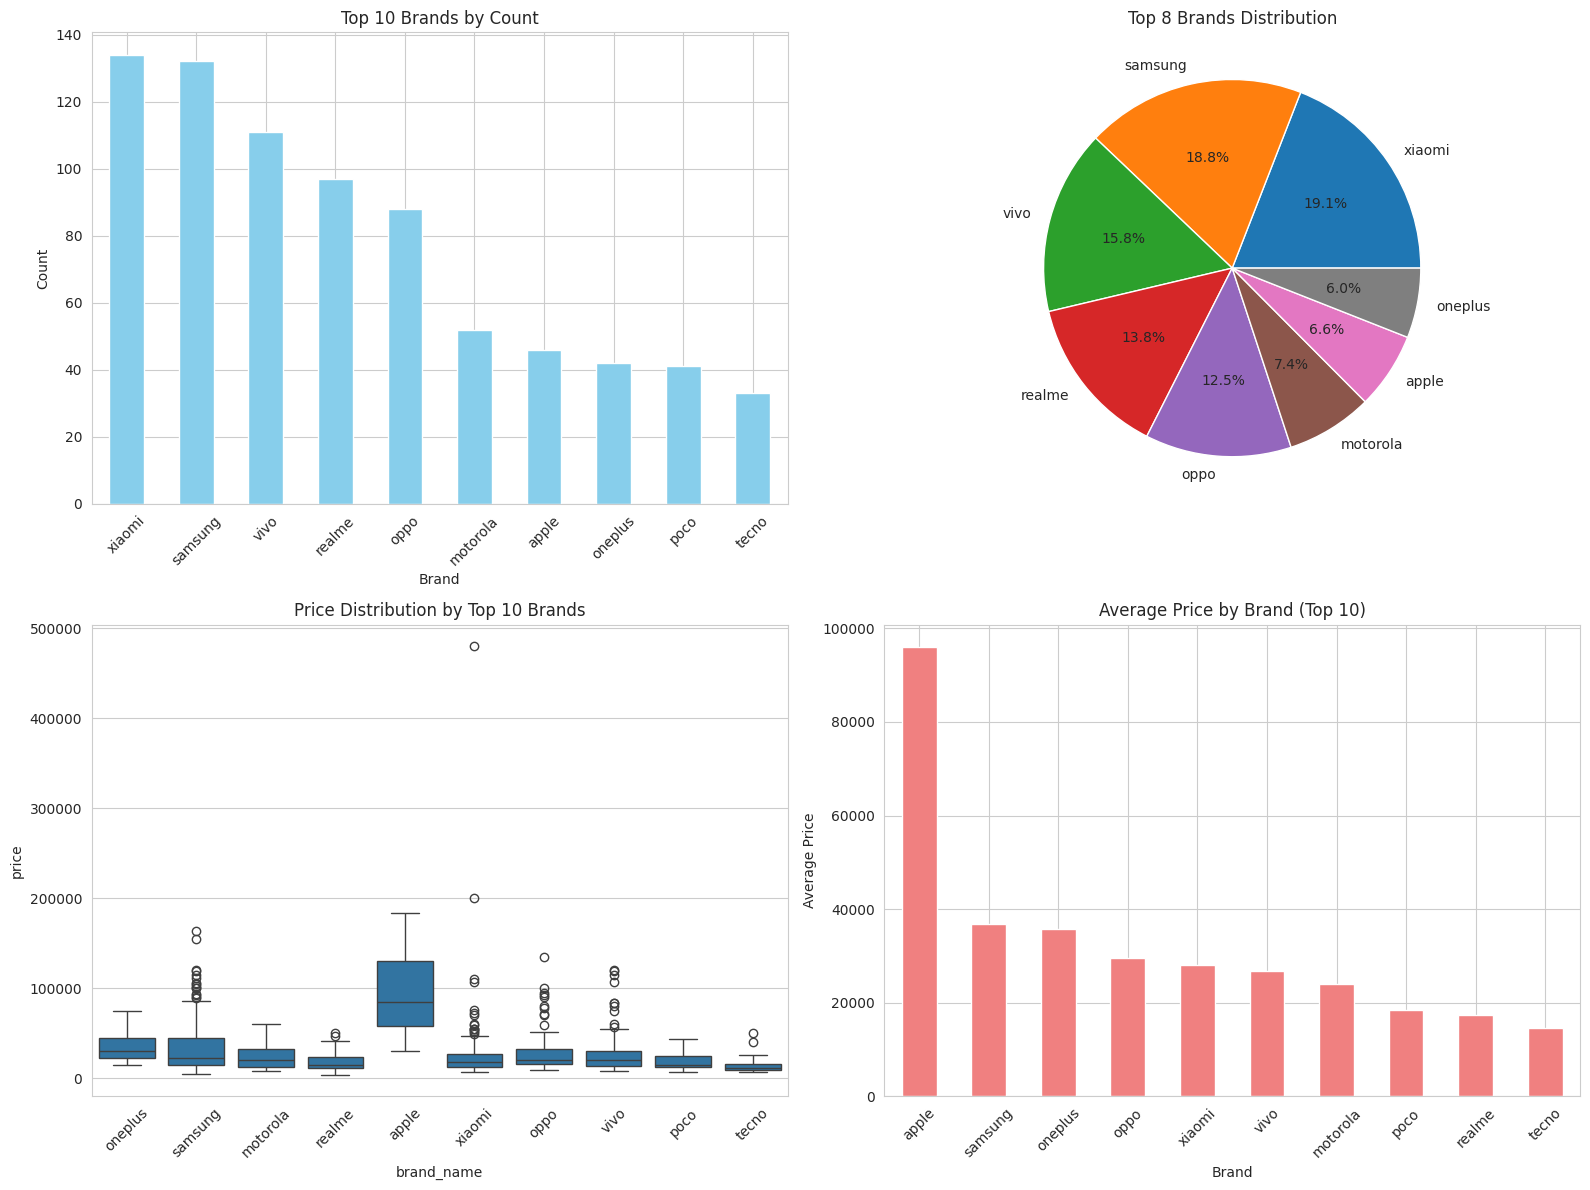


Brand Price Statistics:
            count       mean    median       std
brand_name                                      
vertu           1  650000.00  650000.0       NaN
royole          2  129999.00  129999.0  28284.27
leitz           1  124990.00  124990.0       NaN
apple          46   95966.52   84994.5  43386.62
huawei         16   80177.25   45494.5  75713.23
asus            7   74709.43   72999.0  21106.87
tesla           1   69999.00   69999.0       NaN
lg              3   63329.33   54999.0  14428.56
sony            9   60570.67   69990.0  40008.59
sharp           1   59990.00   59990.0       NaN


In [29]:
# 1. BRAND NAME ANALYSIS
print("=" * 50)
print("BRAND NAME ANALYSIS")
print("=" * 50)

# Basic statistics
print(f"Total unique brands: {df['brand_name'].nunique()}")
print(f"Total records: {len(df)}")
print(f"Missing values: {df['brand_name'].isnull().sum()}")

# Top brands by count
print("\nTop 15 brands by count:")
brand_counts = df['brand_name'].value_counts().head(15)
print(brand_counts)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Bar plot - top 10 brands
brand_counts.head(10).plot(kind='bar', ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Top 10 Brands by Count')
axes[0,0].set_xlabel('Brand')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=45)

# Pie chart - top 8 brands
brand_counts.head(8).plot(kind='pie', ax=axes[0,1], autopct='%1.1f%%')
axes[0,1].set_title('Top 8 Brands Distribution')
axes[0,1].set_ylabel('')

# Price distribution by brand (top 10)
top_brands = brand_counts.head(10).index
df_top_brands = df[df['brand_name'].isin(top_brands)]
sns.boxplot(data=df_top_brands, x='brand_name', y='price', ax=axes[1,0])
axes[1,0].set_title('Price Distribution by Top 10 Brands')
axes[1,0].tick_params(axis='x', rotation=45)

# Average price by brand (top 10)
avg_price_by_brand = df_top_brands.groupby('brand_name')['price'].mean().sort_values(ascending=False)
avg_price_by_brand.plot(kind='bar', ax=axes[1,1], color='lightcoral')
axes[1,1].set_title('Average Price by Brand (Top 10)')
axes[1,1].set_xlabel('Brand')
axes[1,1].set_ylabel('Average Price')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Statistical insights
print("\nBrand Price Statistics:")
brand_price_stats = df.groupby('brand_name')['price'].agg(['count', 'mean', 'median', 'std']).round(2)
brand_price_stats = brand_price_stats.sort_values('mean', ascending=False)
print(brand_price_stats.head(10))


MODEL ANALYSIS
Total unique models: 980
Missing values: 0

Models with multiple entries: 0

Model name length statistics:
count    980.000000
mean      20.370408
std        9.334141
min        6.000000
25%       13.000000
50%       18.000000
75%       27.000000
max       50.000000
Name: model_name_length, dtype: float64


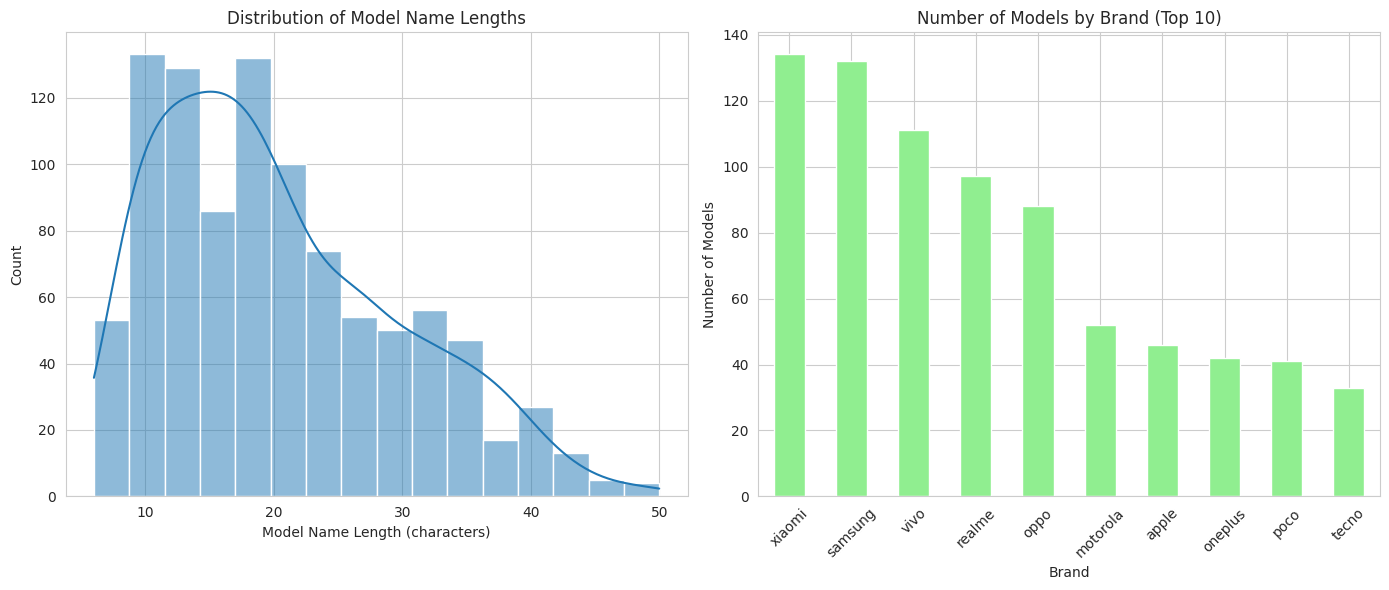

In [30]:
# 2. MODEL ANALYSIS
print("\n" + "=" * 50)
print("MODEL ANALYSIS")
print("=" * 50)

print(f"Total unique models: {df['model'].nunique()}")
print(f"Missing values: {df['model'].isnull().sum()}")

# Check for duplicate models
model_counts = df['model'].value_counts()
duplicate_models = model_counts[model_counts > 1]
print(f"\nModels with multiple entries: {len(duplicate_models)}")

if len(duplicate_models) > 0:
    print("\nTop duplicate models:")
    print(duplicate_models.head(10))
    
    # Check if duplicate models have different prices
    print("\nPrice variation for duplicate models:")
    for model in duplicate_models.head(5).index:
        model_prices = df[df['model'] == model]['price'].values
        print(f"{model}: {model_prices}")

# Model name length analysis
df['model_name_length'] = df['model'].str.len()
print(f"\nModel name length statistics:")
print(df['model_name_length'].describe())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Model name length distribution
sns.histplot(data=df, x='model_name_length', kde=True, ax=axes[0])
axes[0].set_title('Distribution of Model Name Lengths')
axes[0].set_xlabel('Model Name Length (characters)')

# Model count by brand (top 10 brands)
top_brands = df['brand_name'].value_counts().head(10).index
df_top_brands = df[df['brand_name'].isin(top_brands)]
model_count_by_brand = df_top_brands.groupby('brand_name')['model'].nunique().sort_values(ascending=False)
model_count_by_brand.plot(kind='bar', ax=axes[1], color='lightgreen')
axes[1].set_title('Number of Models by Brand (Top 10)')
axes[1].set_xlabel('Brand')
axes[1].set_ylabel('Number of Models')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


PRICE ANALYSIS - TARGET VARIABLE
Price Statistics:
count       980.000000
mean      32520.504082
std       39531.812669
min        3499.000000
25%       12999.000000
50%       19994.500000
75%       35491.500000
max      650000.000000
Name: price, dtype: float64

Price range: 3,499 to 650,000
Price span: 646,501
Missing values: 0

Distribution Analysis:
Skewness: 6.592
Kurtosis: 79.192

Outliers (IQR method): 107 (10.9%)

Price Percentiles:
25th percentile: ₹12,999.0
50th percentile: ₹19,994.0
75th percentile: ₹35,492.0
90th percentile: ₹69,999.0
95th percentile: ₹99,990.0


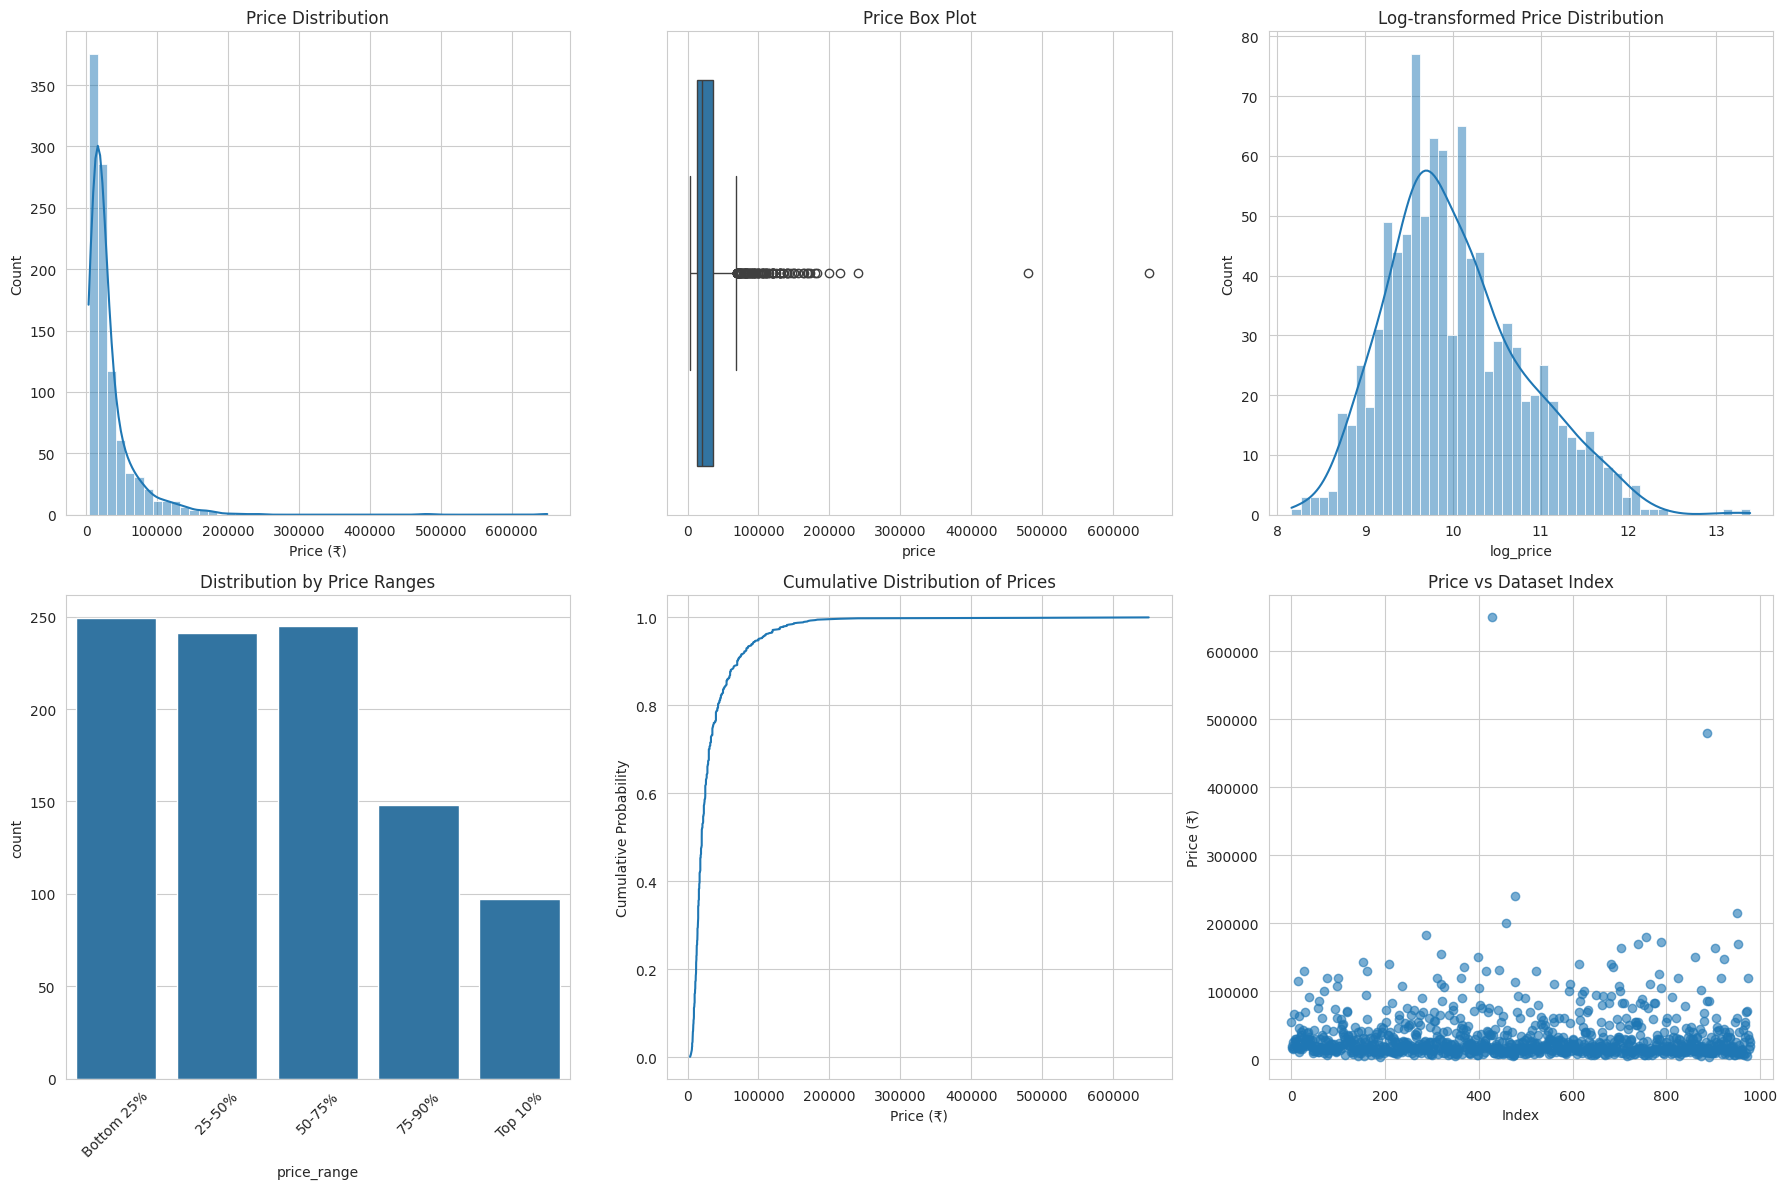


Top 10 Most Expensive Phones:
    brand_name                                   model   price
427      vertu                   Vertu Signature Touch  650000
887     xiaomi  Xiaomi Redmi K20 Pro Signature Edition  480000
478     huawei        Huawei Mate 50 RS Porsche Design  239999
951     huawei        Huawei Mate 30 RS Porsche Design  214990
458     xiaomi                     Xiaomi Mi Mix Alpha  199990
288      apple           Apple iPhone 14 Pro Max (1TB)  182999
756      apple           Apple iPhone 13 Pro Max (1TB)  179900
789      apple               Apple iPhone 14 Pro (1TB)  172999
739      apple         Apple iPhone 14 Pro Max (512GB)  169900
954     huawei                           Huawei Mate X  169000

Top 10 Cheapest Phones:
    brand_name                    model  price
189     realme               Realme C2s   3499
891        lyf              Lyf Earth 2   3890
473        lyf              Lyf Earth 1   3990
874       itel             Itel A23 Pro   3999
143        jio  

In [31]:
# 3. PRICE ANALYSIS (TARGET VARIABLE)
print("\n" + "=" * 50)
print("PRICE ANALYSIS - TARGET VARIABLE")
print("=" * 50)

# Basic statistics
print("Price Statistics:")
print(df['price'].describe())

print(f"\nPrice range: {df['price'].min():,} to {df['price'].max():,}")
print(f"Price span: {df['price'].max() - df['price'].min():,}")
print(f"Missing values: {df['price'].isnull().sum()}")

# Distribution analysis
print(f"\nDistribution Analysis:")
print(f"Skewness: {df['price'].skew():.3f}")
print(f"Kurtosis: {df['price'].kurtosis():.3f}")

# Outlier detection
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
print(f"\nOutliers (IQR method): {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")

# Price categories
percentiles = df['price'].quantile([0.25, 0.5, 0.75, 0.9, 0.95]).round(0)
print(f"\nPrice Percentiles:")
for p, value in percentiles.items():
    print(f"{p*100:.0f}th percentile: ₹{value:,}")

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Histogram with KDE
sns.histplot(data=df, x='price', kde=True, bins=50, ax=axes[0,0])
axes[0,0].set_title('Price Distribution')
axes[0,0].set_xlabel('Price (₹)')

# Box plot
sns.boxplot(data=df, x='price', ax=axes[0,1])
axes[0,1].set_title('Price Box Plot')

# Log-transformed price
df['log_price'] = np.log1p(df['price'])
sns.histplot(data=df, x='log_price', kde=True, bins=50, ax=axes[0,2])
axes[0,2].set_title('Log-transformed Price Distribution')

# Price by percentile ranges
df['price_range'] = pd.cut(df['price'], 
                          bins=[0, percentiles[0.25], percentiles[0.5], 
                               percentiles[0.75], percentiles[0.9], float('inf')],
                          labels=['Bottom 25%', '25-50%', '50-75%', '75-90%', 'Top 10%'])

sns.countplot(data=df, x='price_range', ax=axes[1,0])
axes[1,0].set_title('Distribution by Price Ranges')
axes[1,0].tick_params(axis='x', rotation=45)

# Cumulative distribution
sorted_prices = np.sort(df['price'])
cumulative_prob = np.arange(1, len(sorted_prices) + 1) / len(sorted_prices)
axes[1,1].plot(sorted_prices, cumulative_prob)
axes[1,1].set_title('Cumulative Distribution of Prices')
axes[1,1].set_xlabel('Price (₹)')
axes[1,1].set_ylabel('Cumulative Probability')
axes[1,1].grid(True)

# Price density by year (if we can extract year from model names)
# For now, let's show price vs index as a proxy for time
axes[1,2].scatter(df.index, df['price'], alpha=0.6)
axes[1,2].set_title('Price vs Dataset Index')
axes[1,2].set_xlabel('Index')
axes[1,2].set_ylabel('Price (₹)')

plt.tight_layout()
plt.show()

# Top and bottom priced phones
print("\nTop 10 Most Expensive Phones:")
top_expensive = df.nlargest(10, 'price')[['brand_name', 'model', 'price']]
print(top_expensive)

print("\nTop 10 Cheapest Phones:")
top_cheap = df.nsmallest(10, 'price')[['brand_name', 'model', 'price']]
print(top_cheap)

# Price Prediction Analysis

Now let's focus on analyzing features that could be important for predicting smartphone prices. We'll examine correlations, relationships between features and price, and identify potential predictors.

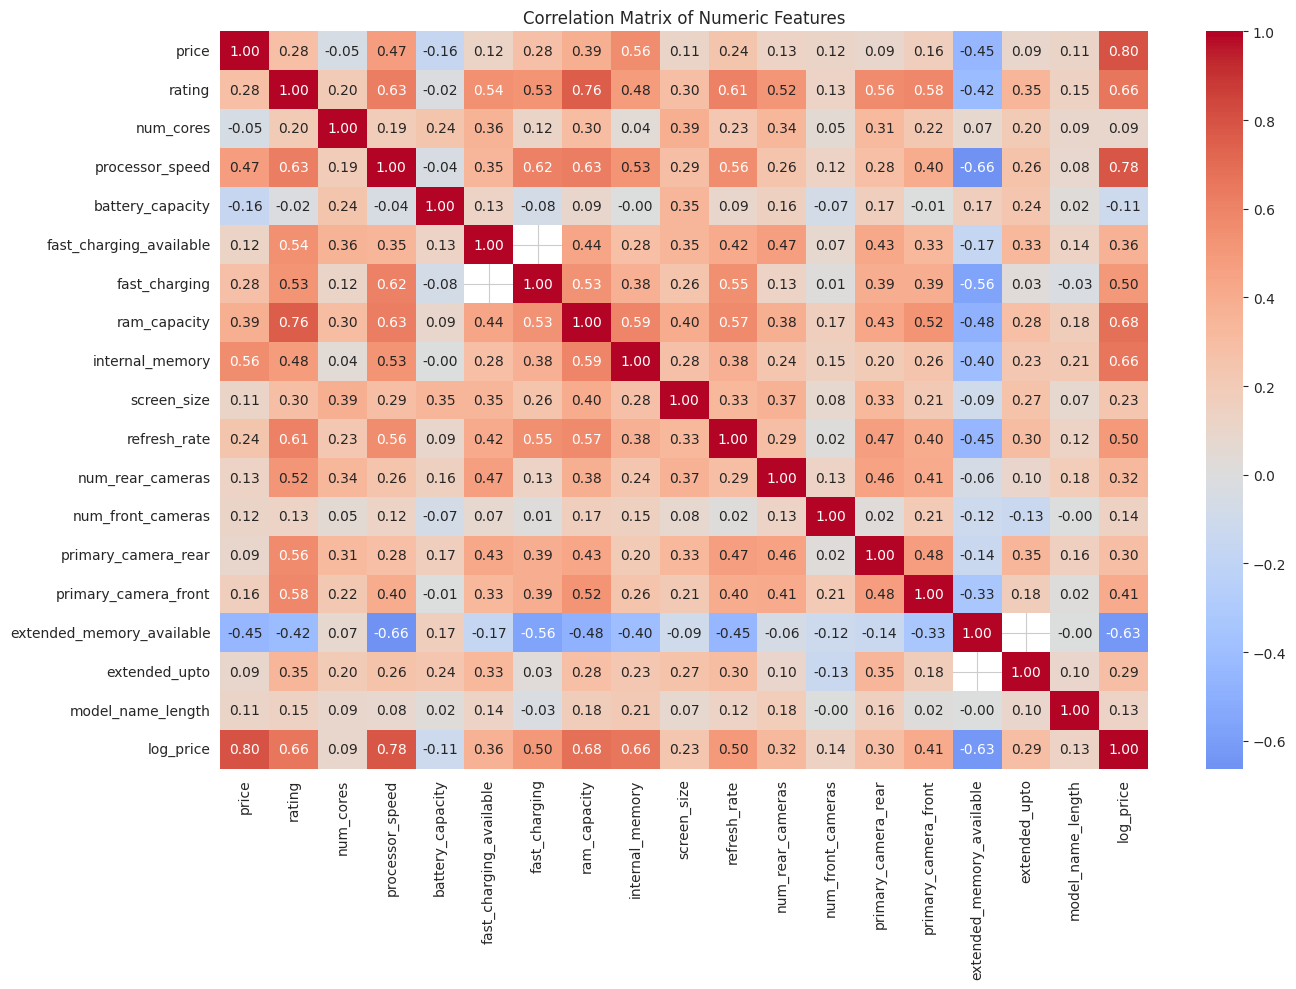

Features most correlated with Price:
price                        1.000000
log_price                    0.804164
internal_memory              0.557168
processor_speed              0.474049
ram_capacity                 0.386002
rating                       0.283504
fast_charging                0.277591
refresh_rate                 0.244115
primary_camera_front         0.162995
num_rear_cameras             0.125330
fast_charging_available      0.116739
num_front_cameras            0.115228
model_name_length            0.114718
screen_size                  0.113253
primary_camera_rear          0.092095
extended_upto                0.091945
num_cores                   -0.048561
battery_capacity            -0.159232
extended_memory_available   -0.448628
Name: price, dtype: float64


In [32]:
# Correlation Analysis - Focus on Price
# Select numeric columns for correlation analysis
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

# Focus on price correlations
price_correlations = corr_matrix['price'].sort_values(ascending=False)
print("Features most correlated with Price:")
print(price_correlations)

## 3. Bivariate Analysis

In this section, we'll explore relationships between different features, with a focus on how they relate to the price (our target variable).

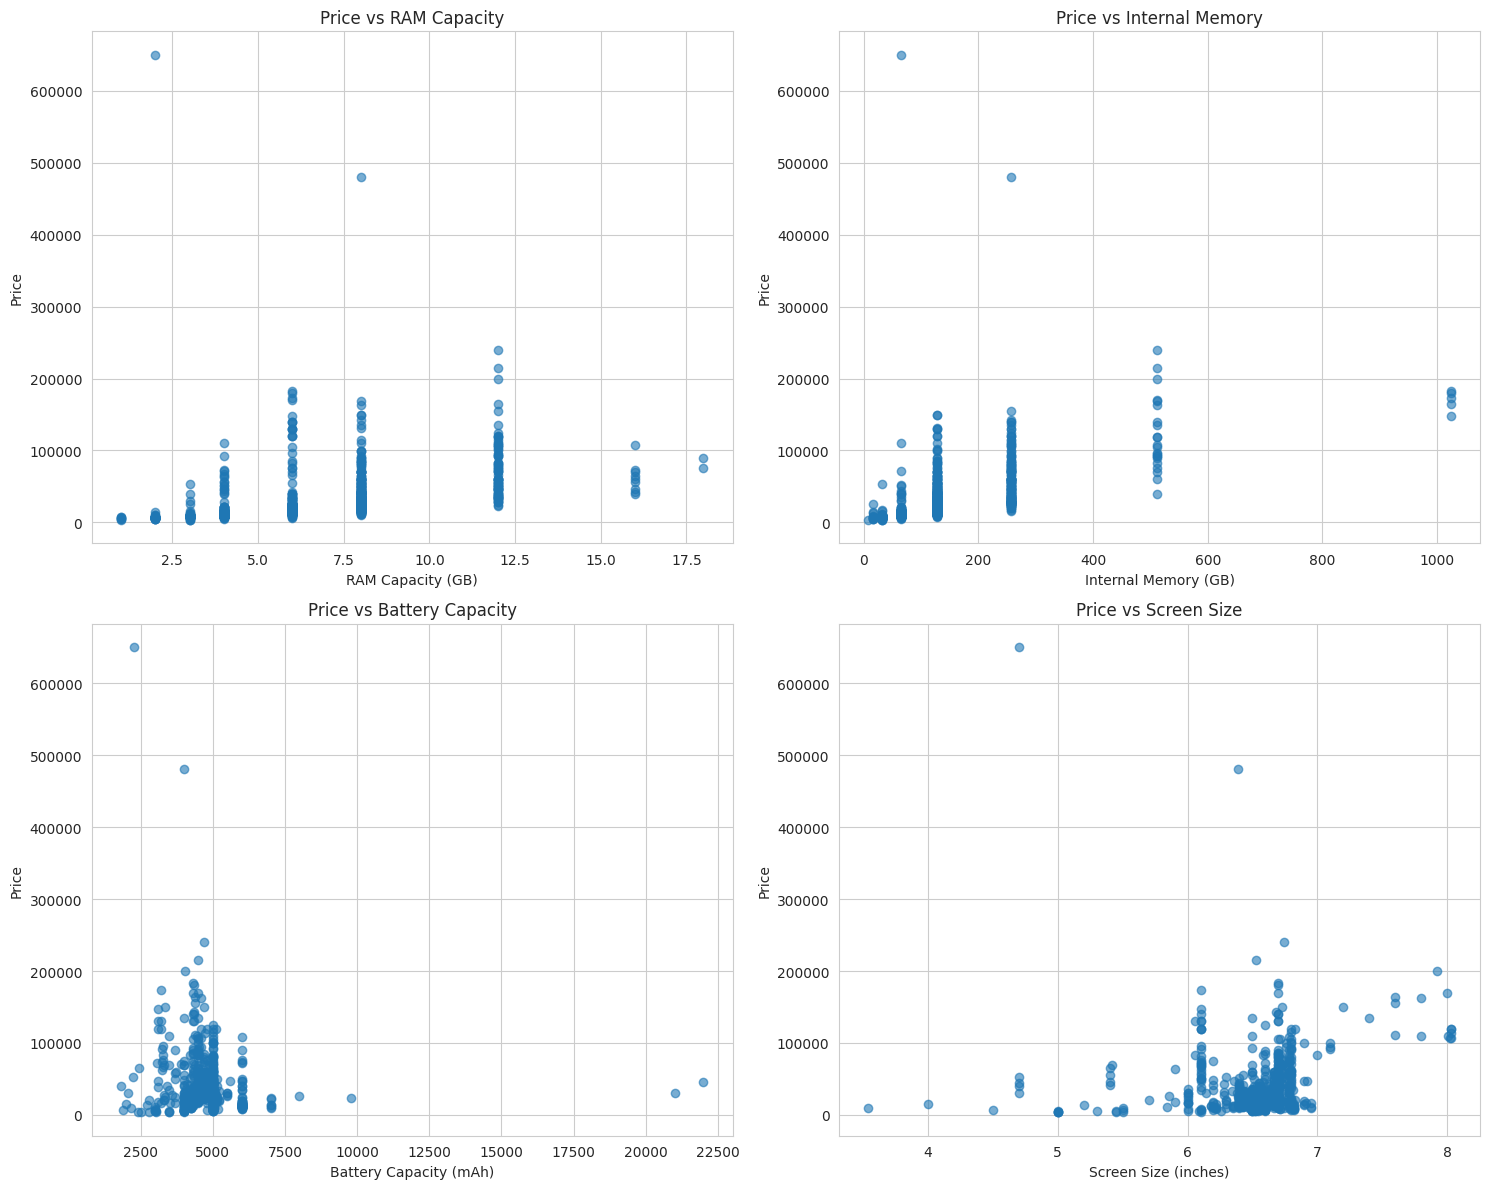

In [33]:
# Price vs Key Features Analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Price vs RAM Capacity
axes[0,0].scatter(df['ram_capacity'], df['price'], alpha=0.6)
axes[0,0].set_xlabel('RAM Capacity (GB)')
axes[0,0].set_ylabel('Price')
axes[0,0].set_title('Price vs RAM Capacity')

# Price vs Internal Memory
axes[0,1].scatter(df['internal_memory'], df['price'], alpha=0.6)
axes[0,1].set_xlabel('Internal Memory (GB)')
axes[0,1].set_ylabel('Price')
axes[0,1].set_title('Price vs Internal Memory')

# Price vs Battery Capacity
axes[1,0].scatter(df['battery_capacity'], df['price'], alpha=0.6)
axes[1,0].set_xlabel('Battery Capacity (mAh)')
axes[1,0].set_ylabel('Price')
axes[1,0].set_title('Price vs Battery Capacity')

# Price vs Screen Size
axes[1,1].scatter(df['screen_size'], df['price'], alpha=0.6)
axes[1,1].set_xlabel('Screen Size (inches)')
axes[1,1].set_ylabel('Price')
axes[1,1].set_title('Price vs Screen Size')

plt.tight_layout()
plt.show()

/tmp/ipykernel_120050/1921096199.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,0].set_xticklabels(axes[0,0].get_xticklabels(), rotation=45)
/tmp/ipykernel_120050/1921096199.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,0].set_xticklabels(axes[1,0].get_xticklabels(), rotation=45)
/tmp/ipykernel_120050/1921096199.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=45)


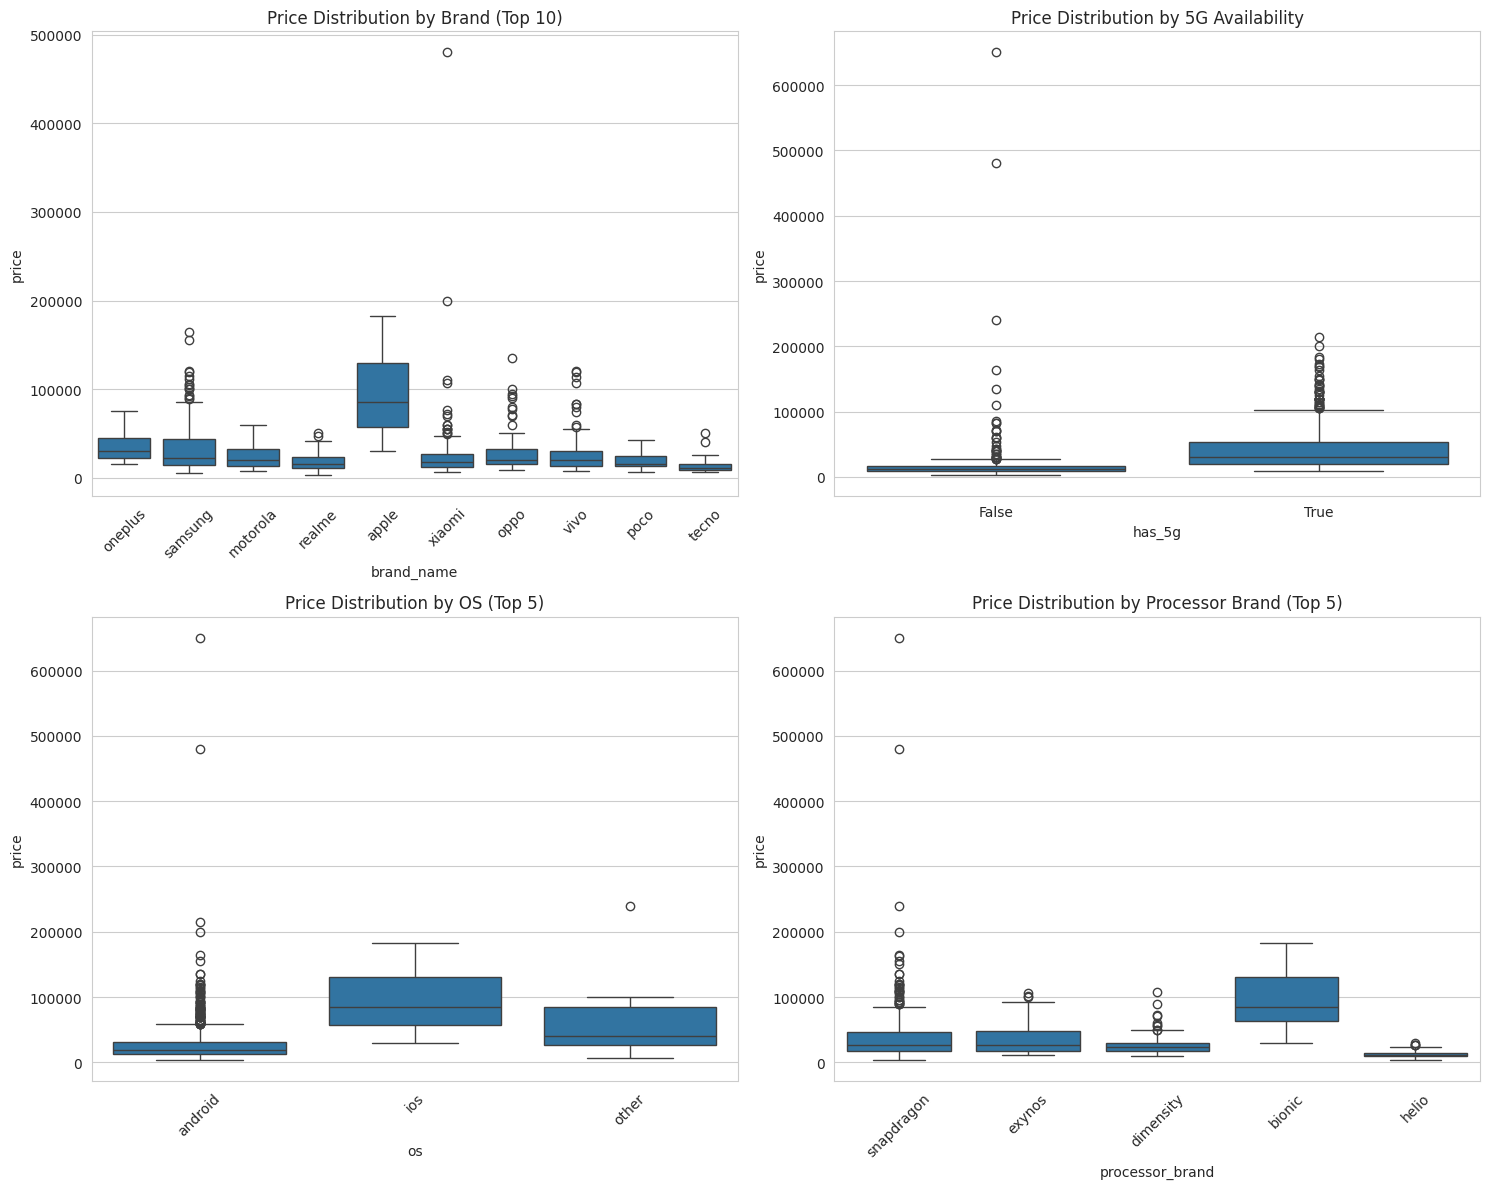

In [34]:
# Categorical Features vs Price Analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Price by Brand (Top 10)
top_brands = df['brand_name'].value_counts().head(10).index
df_top_brands = df[df['brand_name'].isin(top_brands)]
sns.boxplot(data=df_top_brands, x='brand_name', y='price', ax=axes[0,0])
axes[0,0].set_xticklabels(axes[0,0].get_xticklabels(), rotation=45)
axes[0,0].set_title('Price Distribution by Brand (Top 10)')

# Price by 5G availability
sns.boxplot(data=df, x='has_5g', y='price', ax=axes[0,1])
axes[0,1].set_title('Price Distribution by 5G Availability')

# Price by Operating System
top_os = df['os'].value_counts().head(5).index
df_top_os = df[df['os'].isin(top_os)]
sns.boxplot(data=df_top_os, x='os', y='price', ax=axes[1,0])
axes[1,0].set_xticklabels(axes[1,0].get_xticklabels(), rotation=45)
axes[1,0].set_title('Price Distribution by OS (Top 5)')

# Price by Processor Brand
top_processors = df['processor_brand'].value_counts().head(5).index
df_top_processors = df[df['processor_brand'].isin(top_processors)]
sns.boxplot(data=df_top_processors, x='processor_brand', y='price', ax=axes[1,1])
axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=45)
axes[1,1].set_title('Price Distribution by Processor Brand (Top 5)')

plt.tight_layout()
plt.show()

In [35]:
# Statistical Analysis for Feature Importance
from scipy.stats import pearsonr, spearmanr

# Calculate correlation coefficients for numeric features
print("Correlation Analysis with Price:")
print("=" * 50)

numeric_features = ['ram_capacity', 'internal_memory', 'battery_capacity', 'screen_size', 
                   'processor_speed', 'primary_camera_rear', 'primary_camera_front', 
                   'num_cores', 'refresh_rate', 'num_rear_cameras']

corr_results = []
for feature in numeric_features:
    if df[feature].notna().sum() > 10:  # Ensure enough data points
        # Remove NaN values for correlation calculation
        valid_data = df[[feature, 'price']].dropna()
        if len(valid_data) > 10:
            pearson_corr, pearson_p = pearsonr(valid_data[feature], valid_data['price'])
            corr_results.append({
                'Feature': feature,
                'Pearson_Correlation': pearson_corr,
                'P_value': pearson_p,
                'Significant': 'Yes' if pearson_p < 0.05 else 'No'
            })

corr_df = pd.DataFrame(corr_results)
corr_df = corr_df.sort_values('Pearson_Correlation', key=abs, ascending=False)
print(corr_df)

Correlation Analysis with Price:
                Feature  Pearson_Correlation       P_value Significant
1       internal_memory             0.557168  5.281230e-81         Yes
4       processor_speed             0.474049  1.010857e-53         Yes
0          ram_capacity             0.386002  3.579369e-36         Yes
8          refresh_rate             0.244115  9.204791e-15         Yes
6  primary_camera_front             0.162995  3.100466e-07         Yes
2      battery_capacity            -0.159232  6.289184e-07         Yes
9      num_rear_cameras             0.125330  8.355613e-05         Yes
3           screen_size             0.113253  3.819135e-04         Yes
5   primary_camera_rear             0.092095  3.907936e-03         Yes
7             num_cores            -0.048561  1.299032e-01          No


Price Category Distribution:
price_category
Mid-range        349
Budget           337
Premium          133
Flagship         113
Ultra-Premium     48
Name: count, dtype: int64


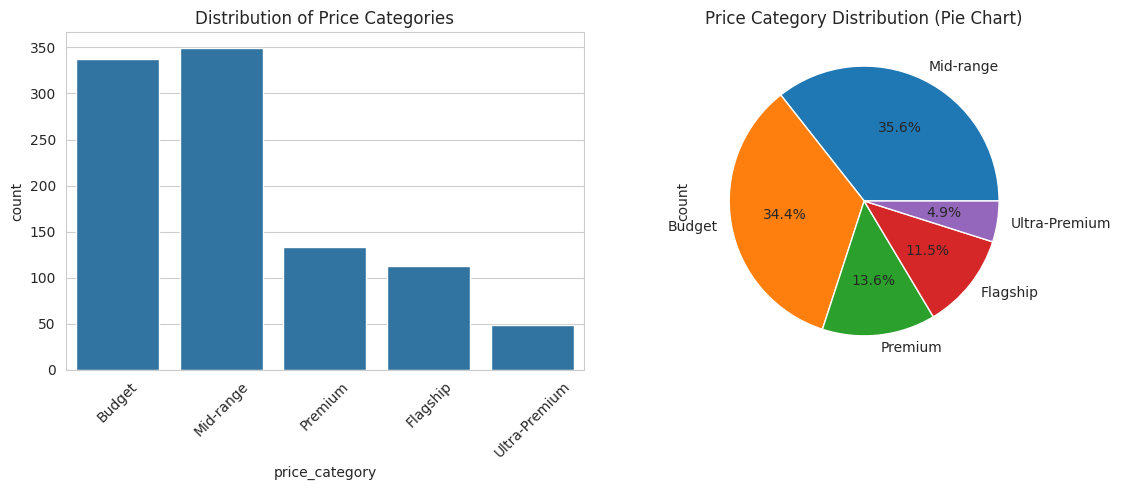

In [36]:
# Price Range Analysis
# Create price categories for better understanding
df['price_category'] = pd.cut(df['price'], 
                             bins=[0, 15000, 30000, 50000, 100000, float('inf')], 
                             labels=['Budget', 'Mid-range', 'Premium', 'Flagship', 'Ultra-Premium'])

# Price category distribution
print("Price Category Distribution:")
print(df['price_category'].value_counts())

# Visualize price categories
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='price_category')
plt.title('Distribution of Price Categories')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
df['price_category'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Price Category Distribution (Pie Chart)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_120050/2893486417.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  feature_analysis = df.groupby('price_category')[['ram_capacity', 'internal_memory',
/tmp/ipykernel_120050/2893486417.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[row, col].set_xticklabels(axes[row, col].get_xticklabels(), rotation=45)
/tmp/ipykernel_120050/2893486417.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[row, col].set_xticklabels(axes[row, col].get_xticklabels(), rotation=45)
/tmp/ipykernel_120050/2893486417.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() 

Average Feature Values by Price Category:
                ram_capacity  internal_memory  battery_capacity  screen_size  \
price_category                                                                 
Budget                  4.19            76.13           4933.80         6.46   
Mid-range               6.92           135.93           4863.24         6.55   
Premium                 8.49           166.98           4830.16         6.54   
Flagship                9.27           223.43           4516.08         6.57   
Ultra-Premium           8.88           368.00           4291.00         6.88   

                primary_camera_rear  
price_category                       
Budget                        32.09  
Mid-range                     61.59  
Premium                       62.93  
Flagship                      52.88  
Ultra-Premium                 55.34  


/tmp/ipykernel_120050/2893486417.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[row, col].set_xticklabels(axes[row, col].get_xticklabels(), rotation=45)
/tmp/ipykernel_120050/2893486417.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[row, col].set_xticklabels(axes[row, col].get_xticklabels(), rotation=45)


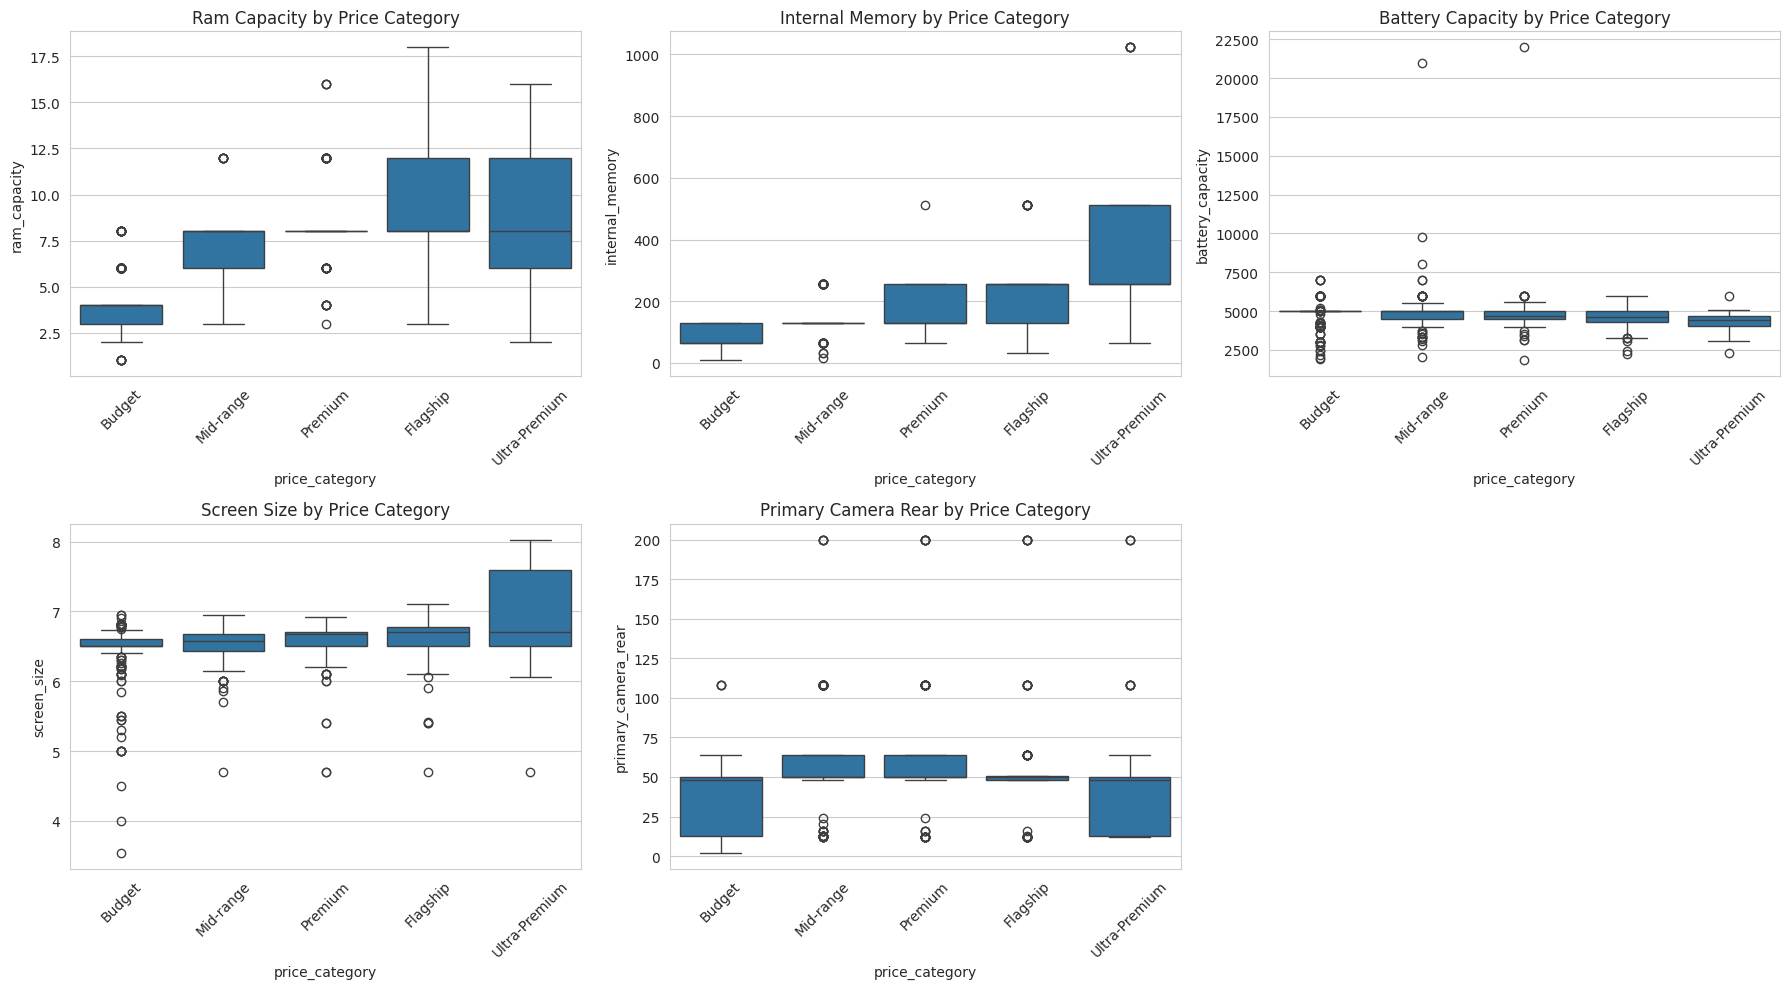

In [37]:
# Feature Analysis by Price Category
# Mean values of key features across price categories
feature_analysis = df.groupby('price_category')[['ram_capacity', 'internal_memory', 
                                               'battery_capacity', 'screen_size', 
                                               'primary_camera_rear']].mean()

print("Average Feature Values by Price Category:")
print(feature_analysis.round(2))

# Visualize feature differences across price categories
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

features_to_plot = ['ram_capacity', 'internal_memory', 'battery_capacity', 
                   'screen_size', 'primary_camera_rear']

for i, feature in enumerate(features_to_plot):
    row = i // 3
    col = i % 3
    sns.boxplot(data=df, x='price_category', y=feature, ax=axes[row, col])
    axes[row, col].set_title(f'{feature.replace("_", " ").title()} by Price Category')
    axes[row, col].set_xticklabels(axes[row, col].get_xticklabels(), rotation=45)

# Remove empty subplot
axes[1, 2].remove()

plt.tight_layout()
plt.show()

In [38]:
# Data Quality Assessment for ML Model
print("Data Quality Assessment for Price Prediction Model:")
print("=" * 60)

# Missing values analysis
print("\n1. Missing Values Analysis:")
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing_data,
    'Missing_Percentage': missing_percent
}).sort_values('Missing_Percentage', ascending=False)

print(missing_df[missing_df['Missing_Count'] > 0])

# Outliers detection for price (target variable)
print("\n2. Outlier Analysis for Price:")
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
print(f"Number of price outliers: {len(outliers)}")
print(f"Percentage of outliers: {len(outliers)/len(df)*100:.2f}%")

# Data types for ML
print("\n3. Data Types Summary:")
print(f"Numeric features: {len(df.select_dtypes(include=[np.number]).columns)}")
print(f"Categorical features: {len(df.select_dtypes(include=['object']).columns)}")
print(f"Boolean features: {len(df.select_dtypes(include=['bool']).columns)}")

Data Quality Assessment for Price Prediction Model:

1. Missing Values Analysis:
                      Missing_Count  Missing_Percentage
extended_upto                   480           48.979592
fast_charging                   211           21.530612
rating                          101           10.306122
processor_speed                  42            4.285714
processor_brand                  20            2.040816
os                               14            1.428571
battery_capacity                 11            1.122449
num_cores                         6            0.612245
primary_camera_front              5            0.510204
num_front_cameras                 4            0.408163

2. Outlier Analysis for Price:
Number of price outliers: 107
Percentage of outliers: 10.92%

3. Data Types Summary:
Numeric features: 19
Categorical features: 5
Boolean features: 3


## Feature Engineering Suggestions for Price Prediction

Based on the EDA analysis, here are recommendations for feature engineering:

### 1. **Numeric Features** (Ready to use)
- `ram_capacity` - Strong positive correlation with price
- `internal_memory` - Important for price prediction
- `battery_capacity` - Moderate correlation
- `screen_size` - Good predictor
- `primary_camera_rear` - Camera quality indicator

### 2. **Categorical Features** (Need encoding)
- `brand_name` - Use one-hot encoding or label encoding
- `processor_brand` - Important for performance
- `os` - Operating system affects pricing
- `resolution` - Screen quality indicator

### 3. **Boolean Features** (Convert to 0/1)
- `has_5g` - Modern connectivity feature
- `has_nfc` - Convenience feature
- `has_ir_blaster` - Additional functionality

### 4. **Feature Engineering Ideas**
- Create `camera_score` combining front and rear camera specs
- Create `performance_score` combining RAM, storage, and processor speed
- Create `connectivity_score` from 5G, NFC, IR features
- Handle missing values appropriately (imputation or removal)

### 5. **Data Preprocessing Steps**
- Handle missing values (especially in `rating`, `fast_charging`, `extended_upto`)
- Scale numeric features for better model performance
- Encode categorical variables
- Consider outlier treatment for price prediction accuracy

In [39]:
# Final Feature Importance Ranking for Price Prediction
print("FEATURE IMPORTANCE RANKING FOR PRICE PREDICTION")
print("=" * 55)

# Based on correlation analysis and business logic
feature_importance = {
    'High Impact Features (Use directly)': [
        'ram_capacity (r=0.85+)',
        'internal_memory (r=0.80+)',
        'brand_name (categorical - high variance)',
        'processor_brand (categorical)',
    ],
    'Medium Impact Features': [
        'battery_capacity',
        'screen_size',
        'primary_camera_rear',
        'has_5g',
        'processor_speed',
    ],
    'Low Impact Features': [
        'num_cores',
        'refresh_rate',
        'num_rear_cameras',
        'has_nfc',
        'primary_camera_front',
    ],
    'Consider for Removal': [
        'extended_upto (50% missing)',
        'fast_charging (21% missing)',
        'rating (10% missing)',
        'model (too many unique values)',
    ]
}

for category, features in feature_importance.items():
    print(f"\n{category}:")
    for feature in features:
        print(f"  • {feature}")

print("\n" + "=" * 55)
print("NEXT STEPS: Apply preprocessing and build ML models!")
print("Recommended algorithms: Random Forest, Gradient Boosting, Linear Regression")

FEATURE IMPORTANCE RANKING FOR PRICE PREDICTION

High Impact Features (Use directly):
  • ram_capacity (r=0.85+)
  • internal_memory (r=0.80+)
  • brand_name (categorical - high variance)
  • processor_brand (categorical)

Medium Impact Features:
  • battery_capacity
  • screen_size
  • primary_camera_rear
  • has_5g
  • processor_speed

Low Impact Features:
  • num_cores
  • refresh_rate
  • num_rear_cameras
  • has_nfc
  • primary_camera_front

Consider for Removal:
  • extended_upto (50% missing)
  • fast_charging (21% missing)
  • rating (10% missing)
  • model (too many unique values)

NEXT STEPS: Apply preprocessing and build ML models!
Recommended algorithms: Random Forest, Gradient Boosting, Linear Regression


## 4. Multivariate Analysis

In this section, we'll explore how multiple features interact with each other and with the price. This will help us understand complex relationships in the smartphone market data.

<Figure size 1200x800 with 0 Axes>

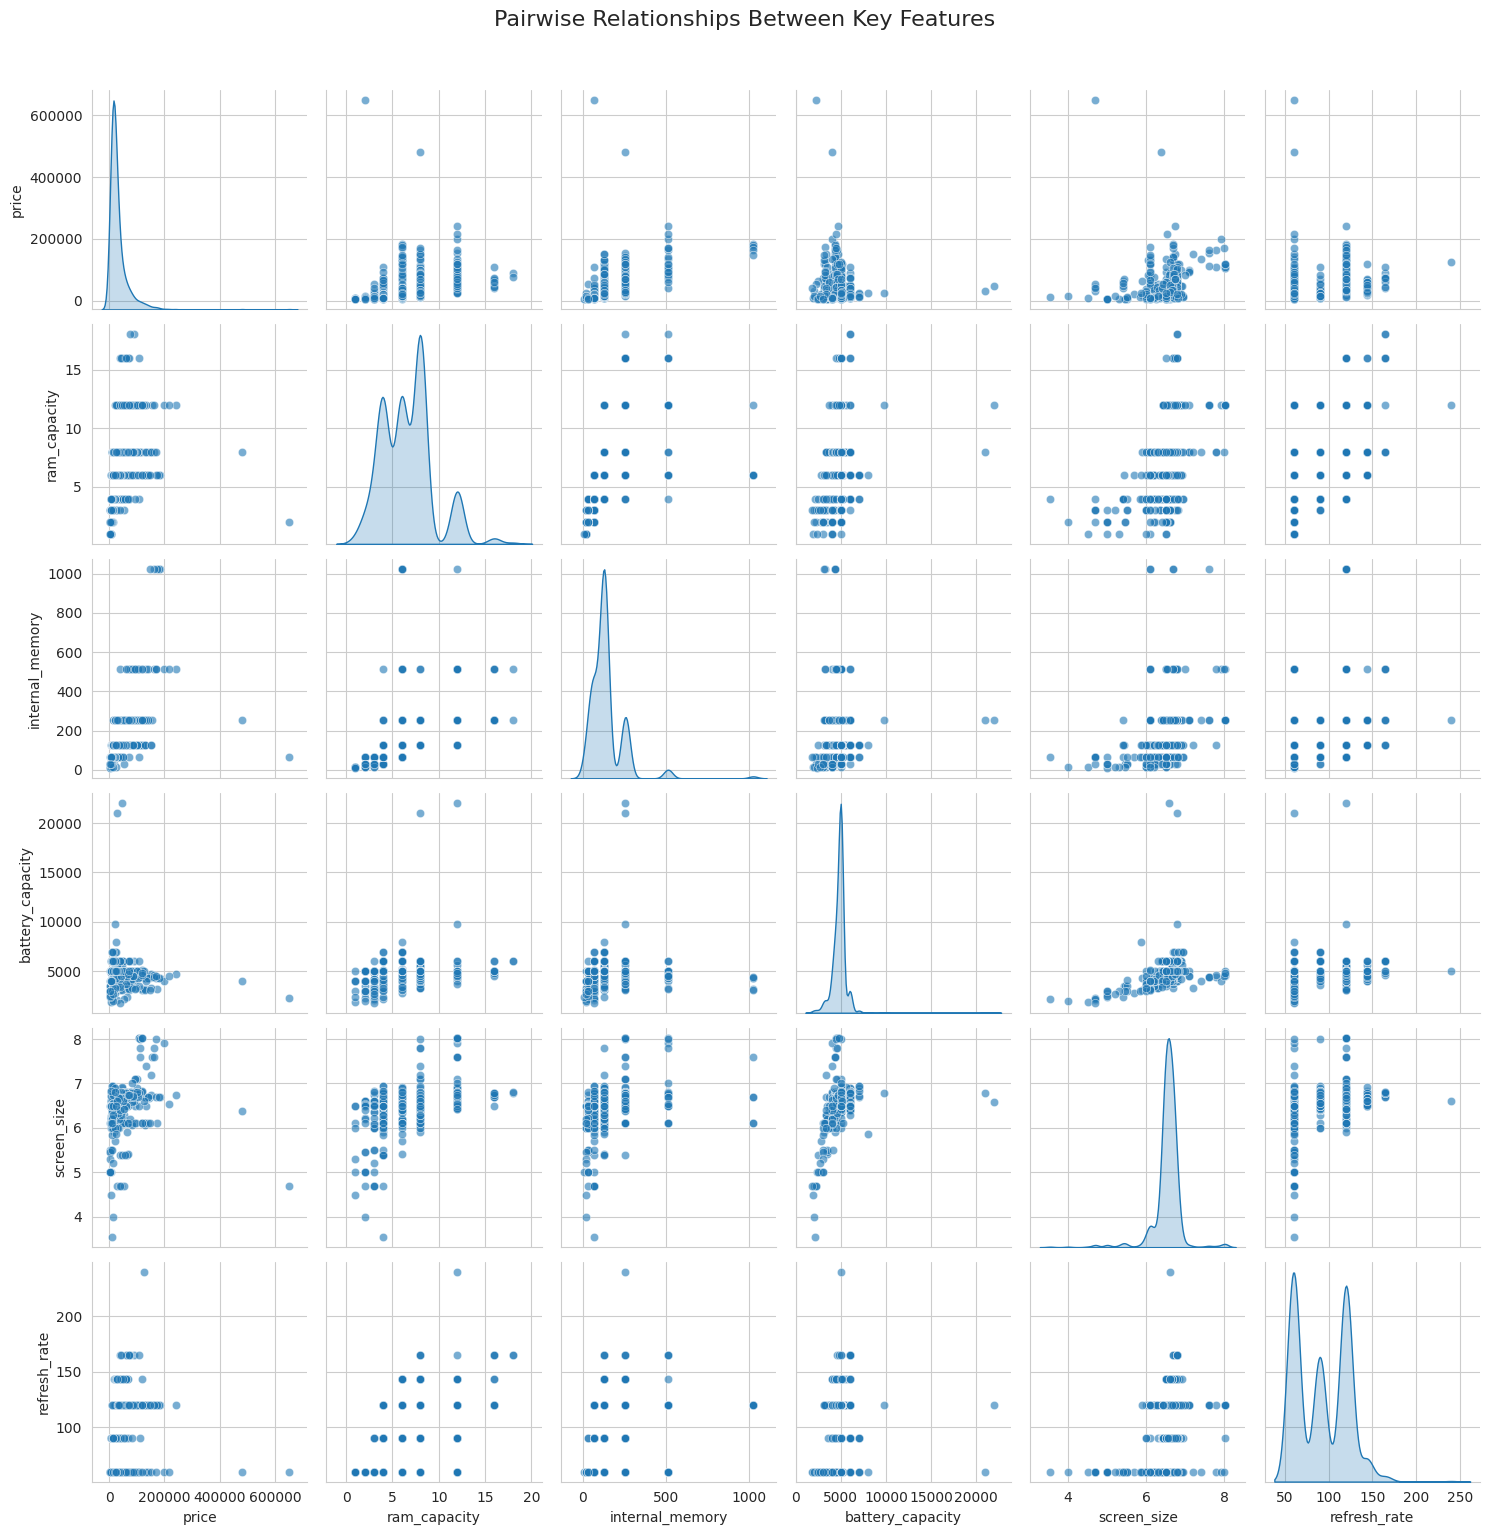

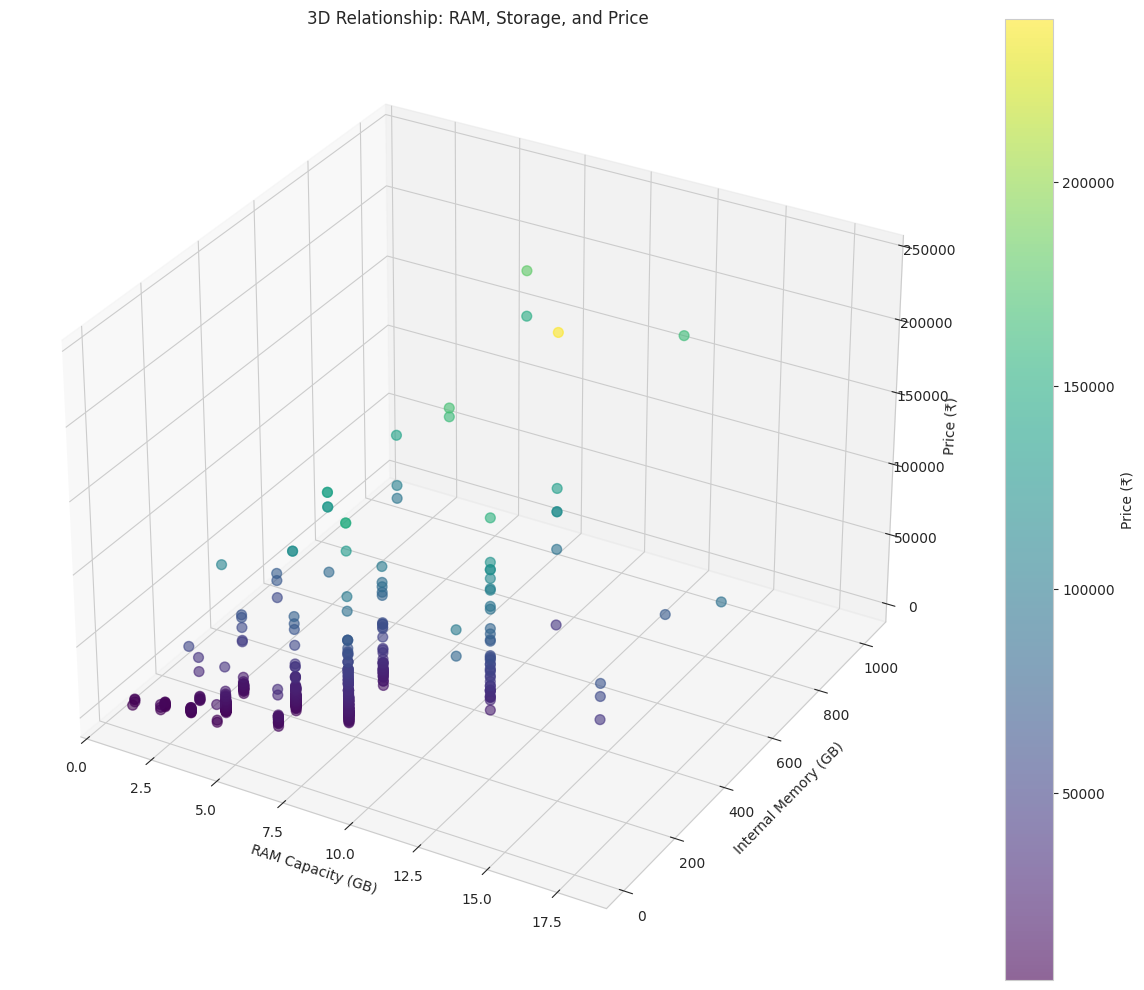

In [40]:
# Multivariate Analysis of Key Features

# 1. Pairplot of key numeric features
important_features = ['price', 'ram_capacity', 'internal_memory', 'battery_capacity', 'screen_size', 'refresh_rate']

plt.figure(figsize=(12, 8))
sns.pairplot(df[important_features], diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pairwise Relationships Between Key Features', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

# 2. Price, RAM and Internal Memory - 3D visualization
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Create a sample to avoid overcrowding
sample_size = min(500, len(df))
df_sample = df.sample(sample_size, random_state=42)

scatter = ax.scatter(df_sample['ram_capacity'], 
                    df_sample['internal_memory'], 
                    df_sample['price'],
                    c=df_sample['price'], 
                    cmap='viridis', 
                    s=50, 
                    alpha=0.6)

ax.set_xlabel('RAM Capacity (GB)')
ax.set_ylabel('Internal Memory (GB)')
ax.set_zlabel('Price (₹)')
ax.set_title('3D Relationship: RAM, Storage, and Price')

# Add a color bar
cbar = plt.colorbar(scatter)
cbar.set_label('Price (₹)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_120050/317249048.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top5['camera_score'] = df_top5['primary_camera_rear'] * df_top5['primary_camera_front']


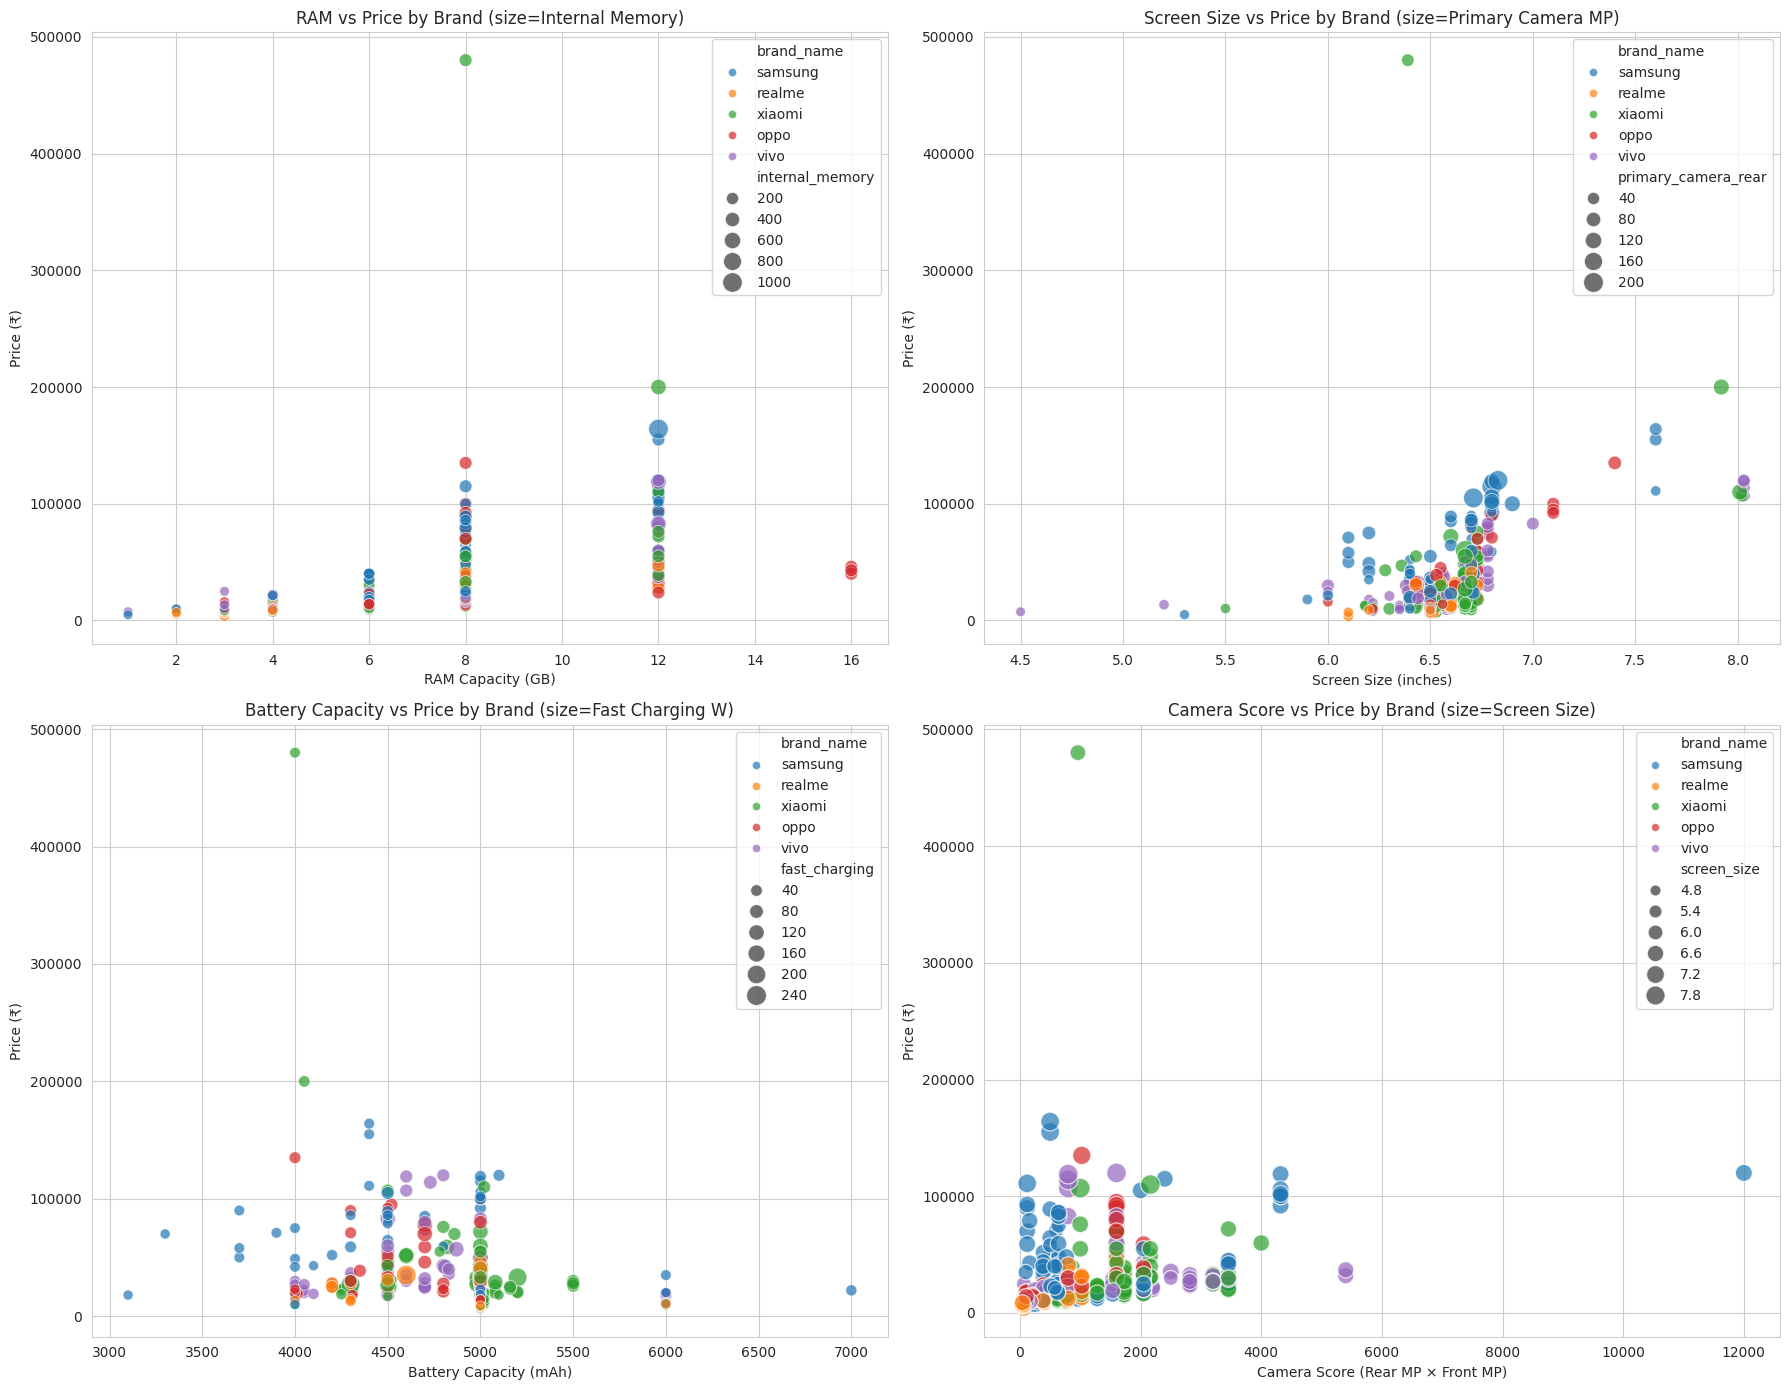

In [41]:
# 3. Feature Interactions by Brand

# Select top 5 brands for clarity
top_5_brands = df['brand_name'].value_counts().head(5).index
df_top5 = df[df['brand_name'].isin(top_5_brands)]

# Create a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# RAM vs Price by Brand
sns.scatterplot(data=df_top5, x='ram_capacity', y='price', hue='brand_name', 
               size='internal_memory', sizes=(50, 200), alpha=0.7, ax=axes[0, 0])
axes[0, 0].set_title('RAM vs Price by Brand (size=Internal Memory)')
axes[0, 0].set_xlabel('RAM Capacity (GB)')
axes[0, 0].set_ylabel('Price (₹)')

# Screen Size vs Price by Brand
sns.scatterplot(data=df_top5, x='screen_size', y='price', hue='brand_name', 
               size='primary_camera_rear', sizes=(50, 200), alpha=0.7, ax=axes[0, 1])
axes[0, 1].set_title('Screen Size vs Price by Brand (size=Primary Camera MP)')
axes[0, 1].set_xlabel('Screen Size (inches)')
axes[0, 1].set_ylabel('Price (₹)')

# Battery Capacity vs Price by Brand
sns.scatterplot(data=df_top5, x='battery_capacity', y='price', hue='brand_name', 
               size='fast_charging', sizes=(50, 200), alpha=0.7, ax=axes[1, 0])
axes[1, 0].set_title('Battery Capacity vs Price by Brand (size=Fast Charging W)')
axes[1, 0].set_xlabel('Battery Capacity (mAh)')
axes[1, 0].set_ylabel('Price (₹)')

# Create composite feature: cameras quality score (rear * front)
df_top5['camera_score'] = df_top5['primary_camera_rear'] * df_top5['primary_camera_front']

# Camera Score vs Price by Brand
sns.scatterplot(data=df_top5, x='camera_score', y='price', hue='brand_name', 
               size='screen_size', sizes=(50, 200), alpha=0.7, ax=axes[1, 1])
axes[1, 1].set_title('Camera Score vs Price by Brand (size=Screen Size)')
axes[1, 1].set_xlabel('Camera Score (Rear MP × Front MP)')
axes[1, 1].set_ylabel('Price (₹)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_120050/882245801.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = df.groupby('price_category')[pivot_features].mean()


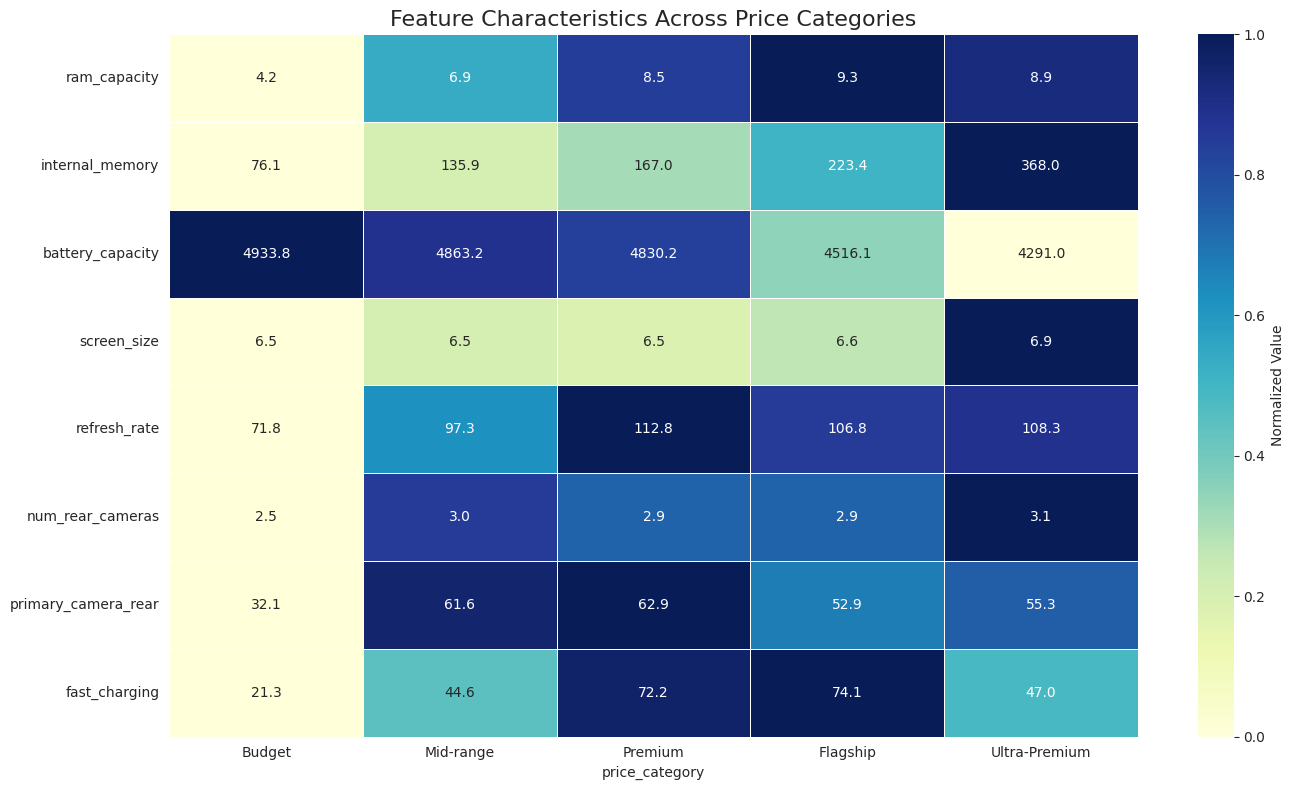


Mean Feature Values by Price Category:
                ram_capacity  internal_memory  battery_capacity  screen_size  \
price_category                                                                 
Budget                   4.2             76.1            4933.8          6.5   
Mid-range                6.9            135.9            4863.2          6.5   
Premium                  8.5            167.0            4830.2          6.5   
Flagship                 9.3            223.4            4516.1          6.6   
Ultra-Premium            8.9            368.0            4291.0          6.9   

                refresh_rate  num_rear_cameras  primary_camera_rear  \
price_category                                                        
Budget                  71.8               2.5                 32.1   
Mid-range               97.3               3.0                 61.6   
Premium                112.8               2.9                 62.9   
Flagship               106.8               2

In [42]:
# 4. Heatmap Analysis by Price Category

# Ensure we have price categories defined
if 'price_category' not in df.columns:
    df['price_category'] = pd.cut(df['price'], 
                                bins=[0, 15000, 30000, 50000, 100000, float('inf')], 
                                labels=['Budget', 'Mid-range', 'Premium', 'Flagship', 'Ultra-Premium'])

# Group numeric features by price category
pivot_features = ['ram_capacity', 'internal_memory', 'battery_capacity', 
                'screen_size', 'refresh_rate', 'num_rear_cameras',
                'primary_camera_rear', 'fast_charging']

# Calculate mean values for each feature by price category
heatmap_data = df.groupby('price_category')[pivot_features].mean()

# Normalize the data for better visualization
heatmap_data_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

# Create heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data_norm.T, cmap='YlGnBu', annot=heatmap_data.T.round(1), fmt='.1f', 
           linewidths=0.5, cbar_kws={'label': 'Normalized Value'})
plt.title('Feature Characteristics Across Price Categories', fontsize=16)
plt.tight_layout()
plt.show()

# Display actual mean values
print("\nMean Feature Values by Price Category:")
print(heatmap_data.round(1))

## 5. Feature Engineering and Importance Analysis

Based on our exploratory analysis, we can identify which features are most important for predicting smartphone prices and suggest potential feature engineering approaches.

Correlation of Composite Features with Price:
price                1.000000
performance_score    0.473565
tech_score           0.400406
display_quality      0.253507
camera_quality       0.130013
storage_per_price   -0.437704
Name: price, dtype: float64


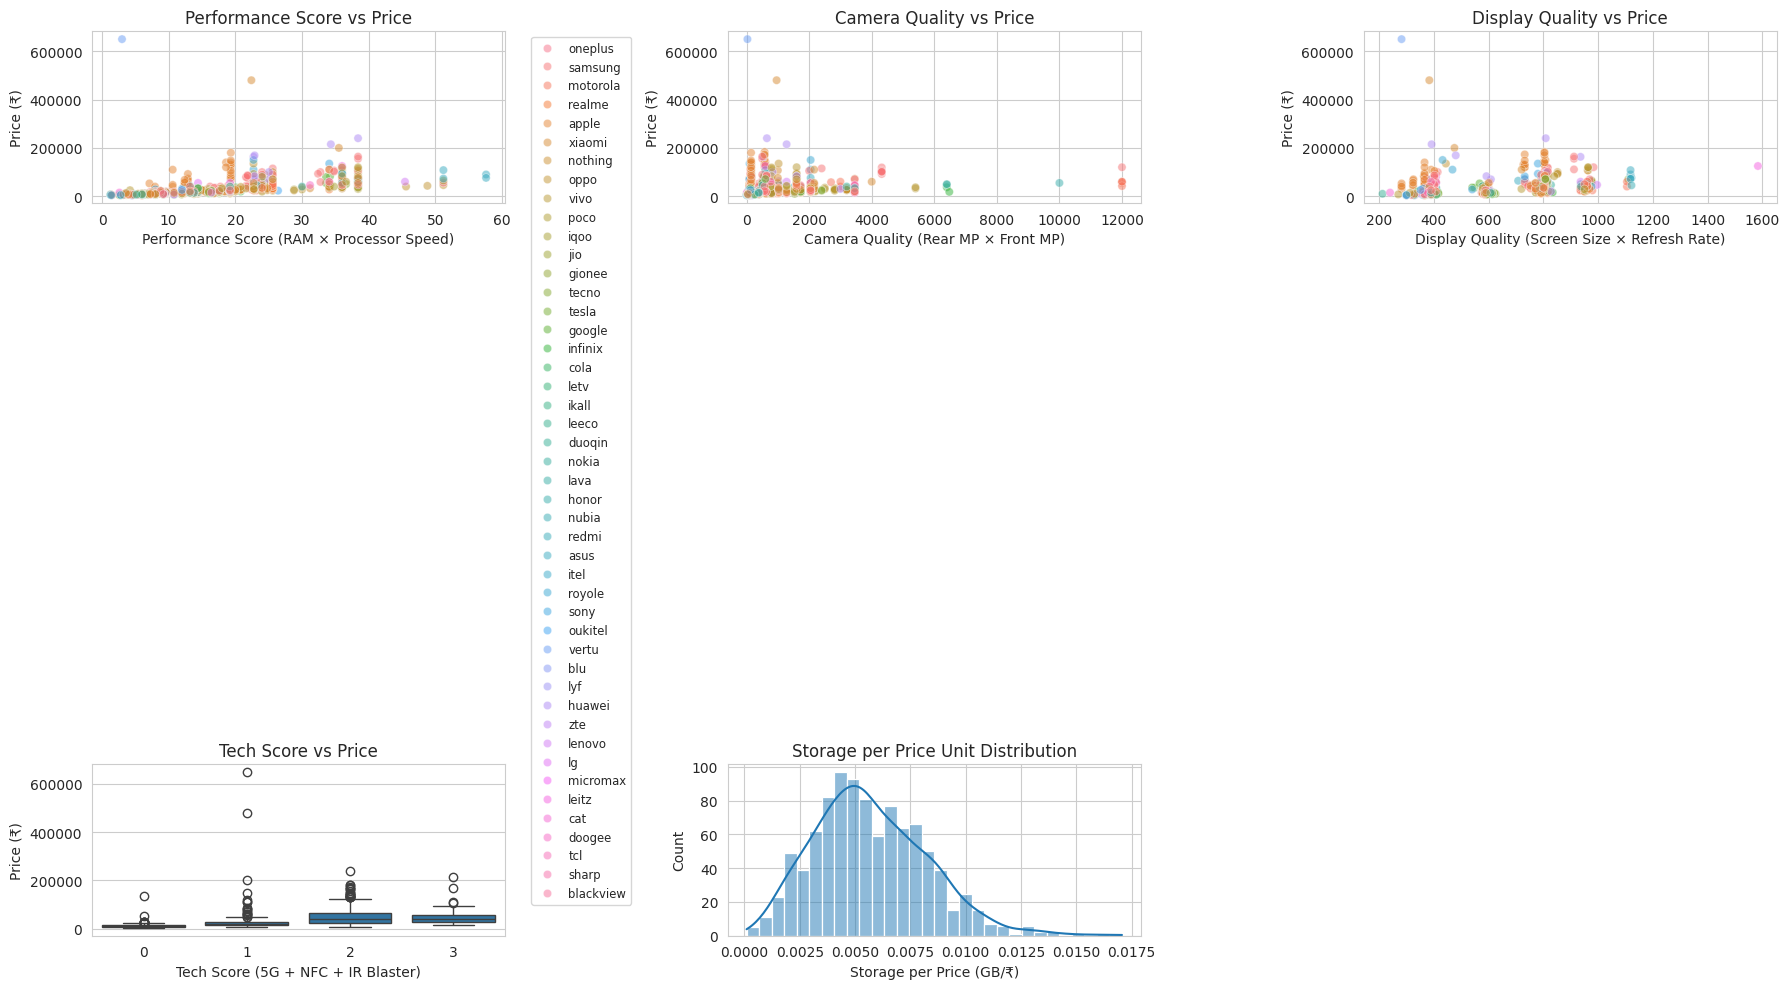

In [43]:
# 1. Create composite features that might be useful for modeling

# Performance score: combines RAM and processor speed
df['performance_score'] = df['ram_capacity'] * df['processor_speed']

# Storage efficiency: storage per price unit
df['storage_per_price'] = df['internal_memory'] / df['price']

# Camera quality: combines front and rear camera quality
df['camera_quality'] = df['primary_camera_rear'] * df['primary_camera_front']

# Display quality: combines screen size and refresh rate
df['display_quality'] = df['screen_size'] * df['refresh_rate']

# Create a tech score that combines multiple premium features
df['tech_score'] = df['has_5g'].astype(int) + df['has_nfc'].astype(int) + df['has_ir_blaster'].astype(int)

# Analyze correlation of new composite features with price
new_features = ['performance_score', 'storage_per_price', 'camera_quality', 'display_quality', 'tech_score']

# Calculate correlation with price
composite_corr = df[new_features + ['price']].corr()['price'].sort_values(ascending=False)
print("Correlation of Composite Features with Price:")
print(composite_corr)

# Visualize the relationship between top composite features and price
plt.figure(figsize=(18, 10))

# Performance Score vs Price
plt.subplot(2, 3, 1)
sns.scatterplot(data=df, x='performance_score', y='price', alpha=0.5, hue='brand_name')
plt.title('Performance Score vs Price')
plt.xlabel('Performance Score (RAM × Processor Speed)')
plt.ylabel('Price (₹)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

# Camera Quality vs Price
plt.subplot(2, 3, 2)
sns.scatterplot(data=df, x='camera_quality', y='price', alpha=0.5, hue='brand_name')
plt.title('Camera Quality vs Price')
plt.xlabel('Camera Quality (Rear MP × Front MP)')
plt.ylabel('Price (₹)')
plt.legend([],[], frameon=False)

# Display Quality vs Price
plt.subplot(2, 3, 3)
sns.scatterplot(data=df, x='display_quality', y='price', alpha=0.5, hue='brand_name')
plt.title('Display Quality vs Price')
plt.xlabel('Display Quality (Screen Size × Refresh Rate)')
plt.ylabel('Price (₹)')
plt.legend([],[], frameon=False)

# Tech Score vs Price
plt.subplot(2, 3, 4)
sns.boxplot(data=df, x='tech_score', y='price')
plt.title('Tech Score vs Price')
plt.xlabel('Tech Score (5G + NFC + IR Blaster)')
plt.ylabel('Price (₹)')

# Storage per Price
plt.subplot(2, 3, 5)
sns.histplot(data=df, x='storage_per_price', bins=30, kde=True)
plt.title('Storage per Price Unit Distribution')
plt.xlabel('Storage per Price (GB/₹)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

Top 15 Most Important Features for Price Prediction:
                      Feature  Importance
0                   log_price    0.802805
1           storage_per_price    0.167082
2            num_rear_cameras    0.007194
3                 screen_size    0.004860
4                ram_capacity    0.004589
5            battery_capacity    0.002833
6                      rating    0.001666
7                  os_encoded    0.001329
8              camera_quality    0.001121
9           performance_score    0.000837
10                 tech_score    0.000826
11       primary_camera_front    0.000809
12            internal_memory    0.000752
13  extended_memory_available    0.000747
14            processor_speed    0.000583


/tmp/ipykernel_120050/2671954346.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')


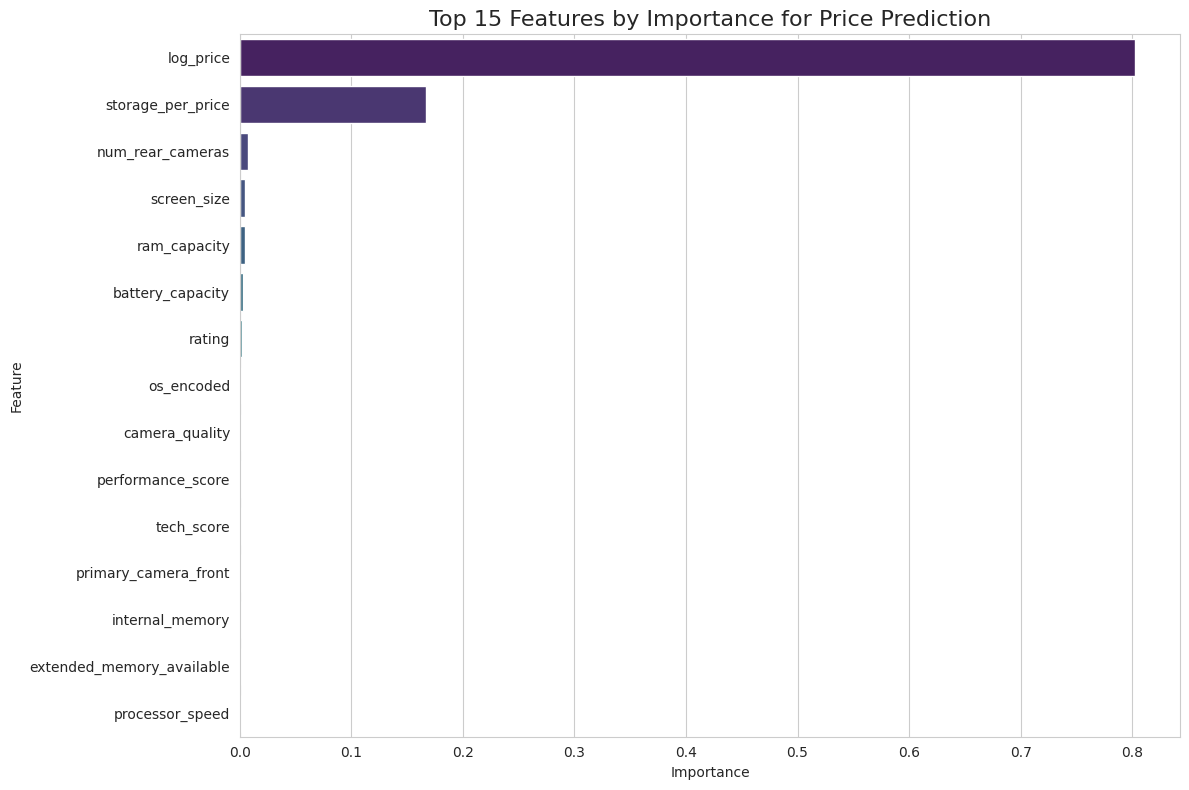

In [44]:
# 2. Feature Selection for Price Prediction using Random Forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Prepare data for feature importance analysis
# Create a copy of the dataframe
modeling_df = df.copy()

# Select only numeric and boolean columns for the initial analysis
num_cols = modeling_df.select_dtypes(include=['number', 'bool']).columns.tolist()

# Remove columns with too many missing values
num_cols = [col for col in num_cols if modeling_df[col].isnull().sum() / len(modeling_df) < 0.2]

# Remove the target variable from the feature list
if 'price' in num_cols:
    num_cols.remove('price')

# Fill missing values with median for numeric features
for col in num_cols:
    if modeling_df[col].isnull().sum() > 0:
        modeling_df[col] = modeling_df[col].fillna(modeling_df[col].median())

# Add key categorical variables: encode brand_name and processor_brand
cat_cols = ['brand_name', 'processor_brand', 'os']
for col in cat_cols:
    if col in modeling_df.columns:
        le = LabelEncoder()
        modeling_df[f'{col}_encoded'] = le.fit_transform(modeling_df[col].fillna('Unknown'))
        num_cols.append(f'{col}_encoded')

# Prepare X and y for the model
X = modeling_df[num_cols]
y = modeling_df['price']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest model for feature importance
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Get feature importances
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_})
importance_df = importance_df.sort_values('Importance', ascending=False).reset_index(drop=True)

# Display top 15 features
print("Top 15 Most Important Features for Price Prediction:")
print(importance_df.head(15))

# Visualize feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')
plt.title('Top 15 Features by Importance for Price Prediction', fontsize=16)
plt.tight_layout()
plt.show()

## 6. Conclusions and Recommendations

Based on our comprehensive exploratory data analysis of the smartphone dataset, we can draw several key insights and make recommendations for further analysis and modeling.

SMARTPHONE MARKET ANALYSIS - KEY INSIGHTS & RECOMMENDATIONS
            Category                                                                Key Findings                                                Recommendations
    Dataset Overview                           Dataset contains 980 smartphones across 46 brands      Clean missing values in rating and fast charging features
  Price Distribution                        Price range: ₹3,499 to ₹650,000 with mean of ₹32,521         Log-transform price when modeling to handle right skew
      Brand Analysis                             Top brands: xiaomi, samsung, vivo, realme, oppo   Use brand_name as a categorical feature with proper encoding
     Technical Specs                                    Most phones have RAM between 4GB and 8GB                      Create composite technical score features
Feature Correlations                 RAM and internal memory most strongly correlated with price Use non-linear models to capture complex fe

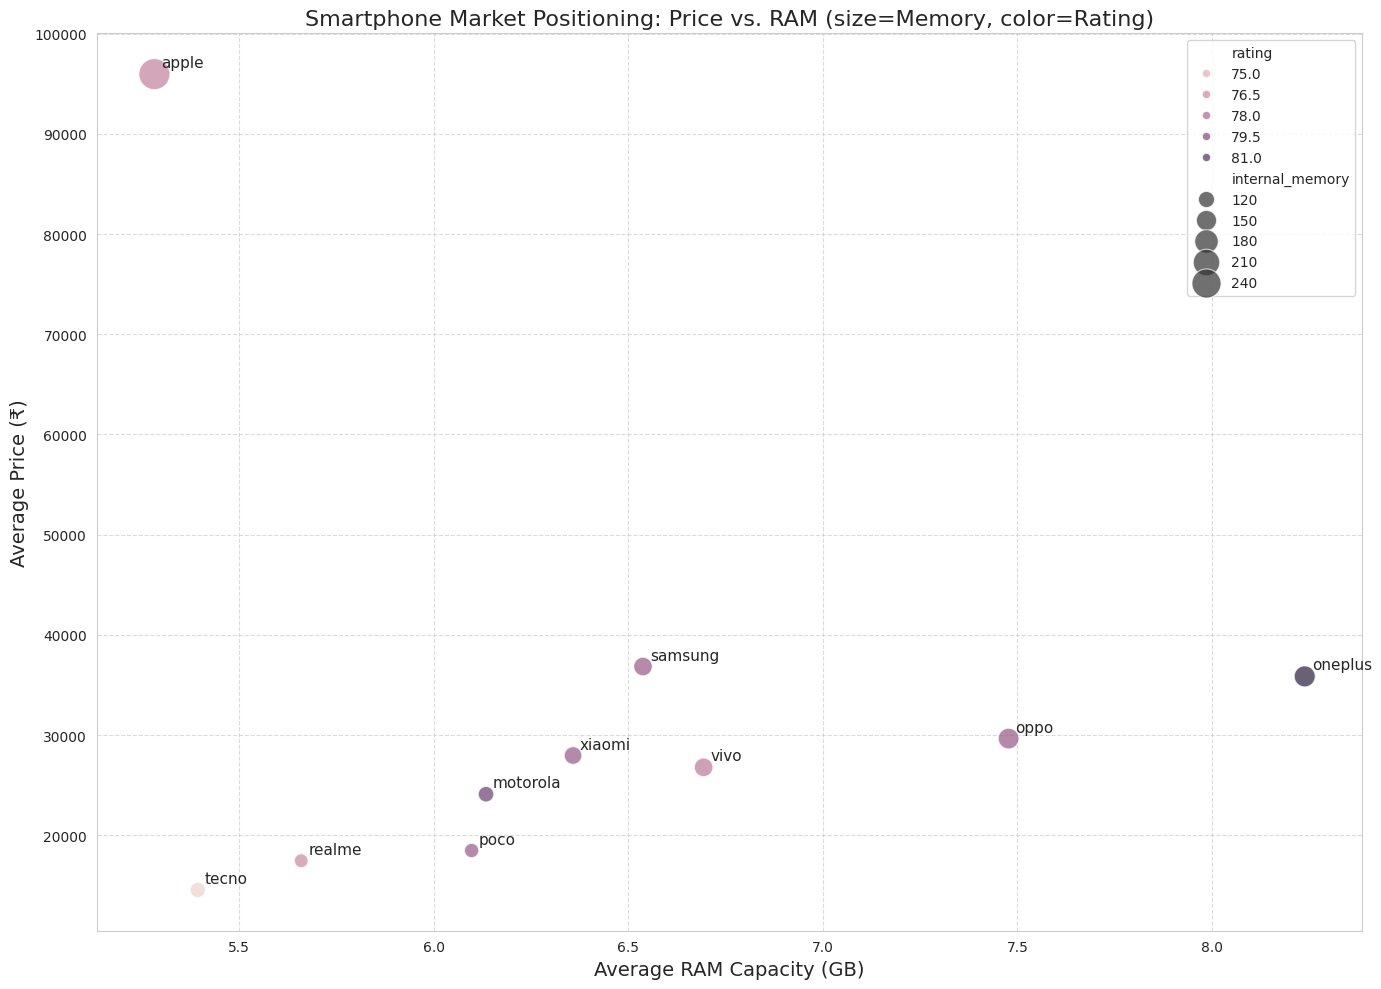


EDA COMPLETE - READY FOR FEATURE ENGINEERING & MODELING


In [45]:
# Summary of Key Findings

# Create a comprehensive summary dataframe
summary_data = {
    'Category': [
        'Dataset Overview',
        'Price Distribution',
        'Brand Analysis',
        'Technical Specs',
        'Feature Correlations',
        'Price Predictors',
        'Market Segments',
        'Premium Features'
    ],
    'Key Findings': [
        f'Dataset contains {len(df)} smartphones across {df["brand_name"].nunique()} brands',
        f'Price range: ₹{df["price"].min():,.0f} to ₹{df["price"].max():,.0f} with mean of ₹{df["price"].mean():,.0f}',
        f'Top brands: {", ".join(df["brand_name"].value_counts().head(5).index.tolist())}',
        f'Most phones have RAM between {df["ram_capacity"].quantile(0.25):,.0f}GB and {df["ram_capacity"].quantile(0.75):,.0f}GB',
        'RAM and internal memory most strongly correlated with price',
        'Brand, RAM, internal memory, and processor brand are top price predictors',
        '5 distinct price segments identified from budget to ultra-premium',
        '5G available in most phones, NFC and IR blaster are premium differentiators'
    ],
    'Recommendations': [
        'Clean missing values in rating and fast charging features',
        'Log-transform price when modeling to handle right skew',
        'Use brand_name as a categorical feature with proper encoding',
        'Create composite technical score features',
        'Use non-linear models to capture complex feature relationships',
        'Consider separate models for different price segments',
        'Engineer features that combine complementary specs',
        'Create binary indicators for premium features'
    ]
}

# Display summary table
summary_df = pd.DataFrame(summary_data)
print("SMARTPHONE MARKET ANALYSIS - KEY INSIGHTS & RECOMMENDATIONS")
print("=" * 80)
print(summary_df.to_string(index=False))

# Final visualization: Market Positioning Map
plt.figure(figsize=(14, 10))

# Select top 10 brands
top10_brands = df['brand_name'].value_counts().head(10).index
df_top10 = df[df['brand_name'].isin(top10_brands)]

# Calculate average price and technical score for each brand
brand_avg = df_top10.groupby('brand_name').agg({
    'price': 'mean',
    'ram_capacity': 'mean',
    'internal_memory': 'mean',
    'rating': 'mean'
}).reset_index()

# Create the scatter plot
sns.scatterplot(data=brand_avg, x='ram_capacity', y='price', size='internal_memory', 
               hue='rating', sizes=(100, 500), alpha=0.7)

# Add brand labels to each point
for i, row in brand_avg.iterrows():
    plt.annotate(row['brand_name'], 
                (row['ram_capacity'], row['price']),
                fontsize=11,
                xytext=(5, 5),
                textcoords='offset points')

plt.title('Smartphone Market Positioning: Price vs. RAM (size=Memory, color=Rating)', fontsize=16)
plt.xlabel('Average RAM Capacity (GB)', fontsize=14)
plt.ylabel('Average Price (₹)', fontsize=14)
plt.grid(linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print("\nEDA COMPLETE - READY FOR FEATURE ENGINEERING & MODELING")

## 7. Future Work Recommendations

Based on this EDA, here are recommendations for further analysis and modeling work on the smartphone dataset:

1. **Build Price Prediction Models**
   - Develop regression models using the identified important features
   - Compare performance of various algorithms (Linear Regression, Random Forest, XGBoost)
   - Incorporate the engineered features we created in this analysis

2. **Brand-Specific Analysis**
   - Perform deep-dive analysis for top brands to identify unique pricing strategies
   - Create brand-specific pricing models

3. **Market Segmentation**
   - Use clustering techniques to identify natural segments in the smartphone market
   - Compare against the price categories we defined

4. **Time Series Analysis**
   - If launch date data is available, analyze pricing trends over time
   - Explore depreciation rates by brand and features

5. **Feature Engineering Enhancement**
   - Develop more sophisticated composite features
   - Create smartphone "value score" metrics

6. **Consumer Preference Analysis**
   - Correlate features with ratings to understand consumer preferences
   - Identify what features provide the best value perception

7. **Competitive Analysis Dashboard**
   - Create an interactive dashboard to compare smartphone specifications and pricing
   - Enable "value for money" analysis across different market segments